# 02 · Judge the lesion outlines

Every lesion section at low magnification, then every lesion at full resolution, then the control
sections. Outlines: <span style="color:#eda100">automatic lesion</span>, <span style="color:#e34948">automatic core</span>,
<span style="color:#e87ba4">manual CORE (dashed)</span>; white rings = Pu.1⁺ cells. Composite: nuclei blue-grey, Pu.1 orange, Iba1 green.

Things to look at
- Does the automatic outline follow the dense Pu.1⁺ / Iba1-bright infiltrate, or does it include ordinary grey matter?
- Is the rim (between automatic lesion and core) a sensible transition zone?
- Are there Pu.1⁺ clusters *without* an outline that should have one (subpial / meningeal infiltrates)?
- Do the control sections stay empty?
- Is the central canal region (section centre) ever outlined?

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Lesion sections

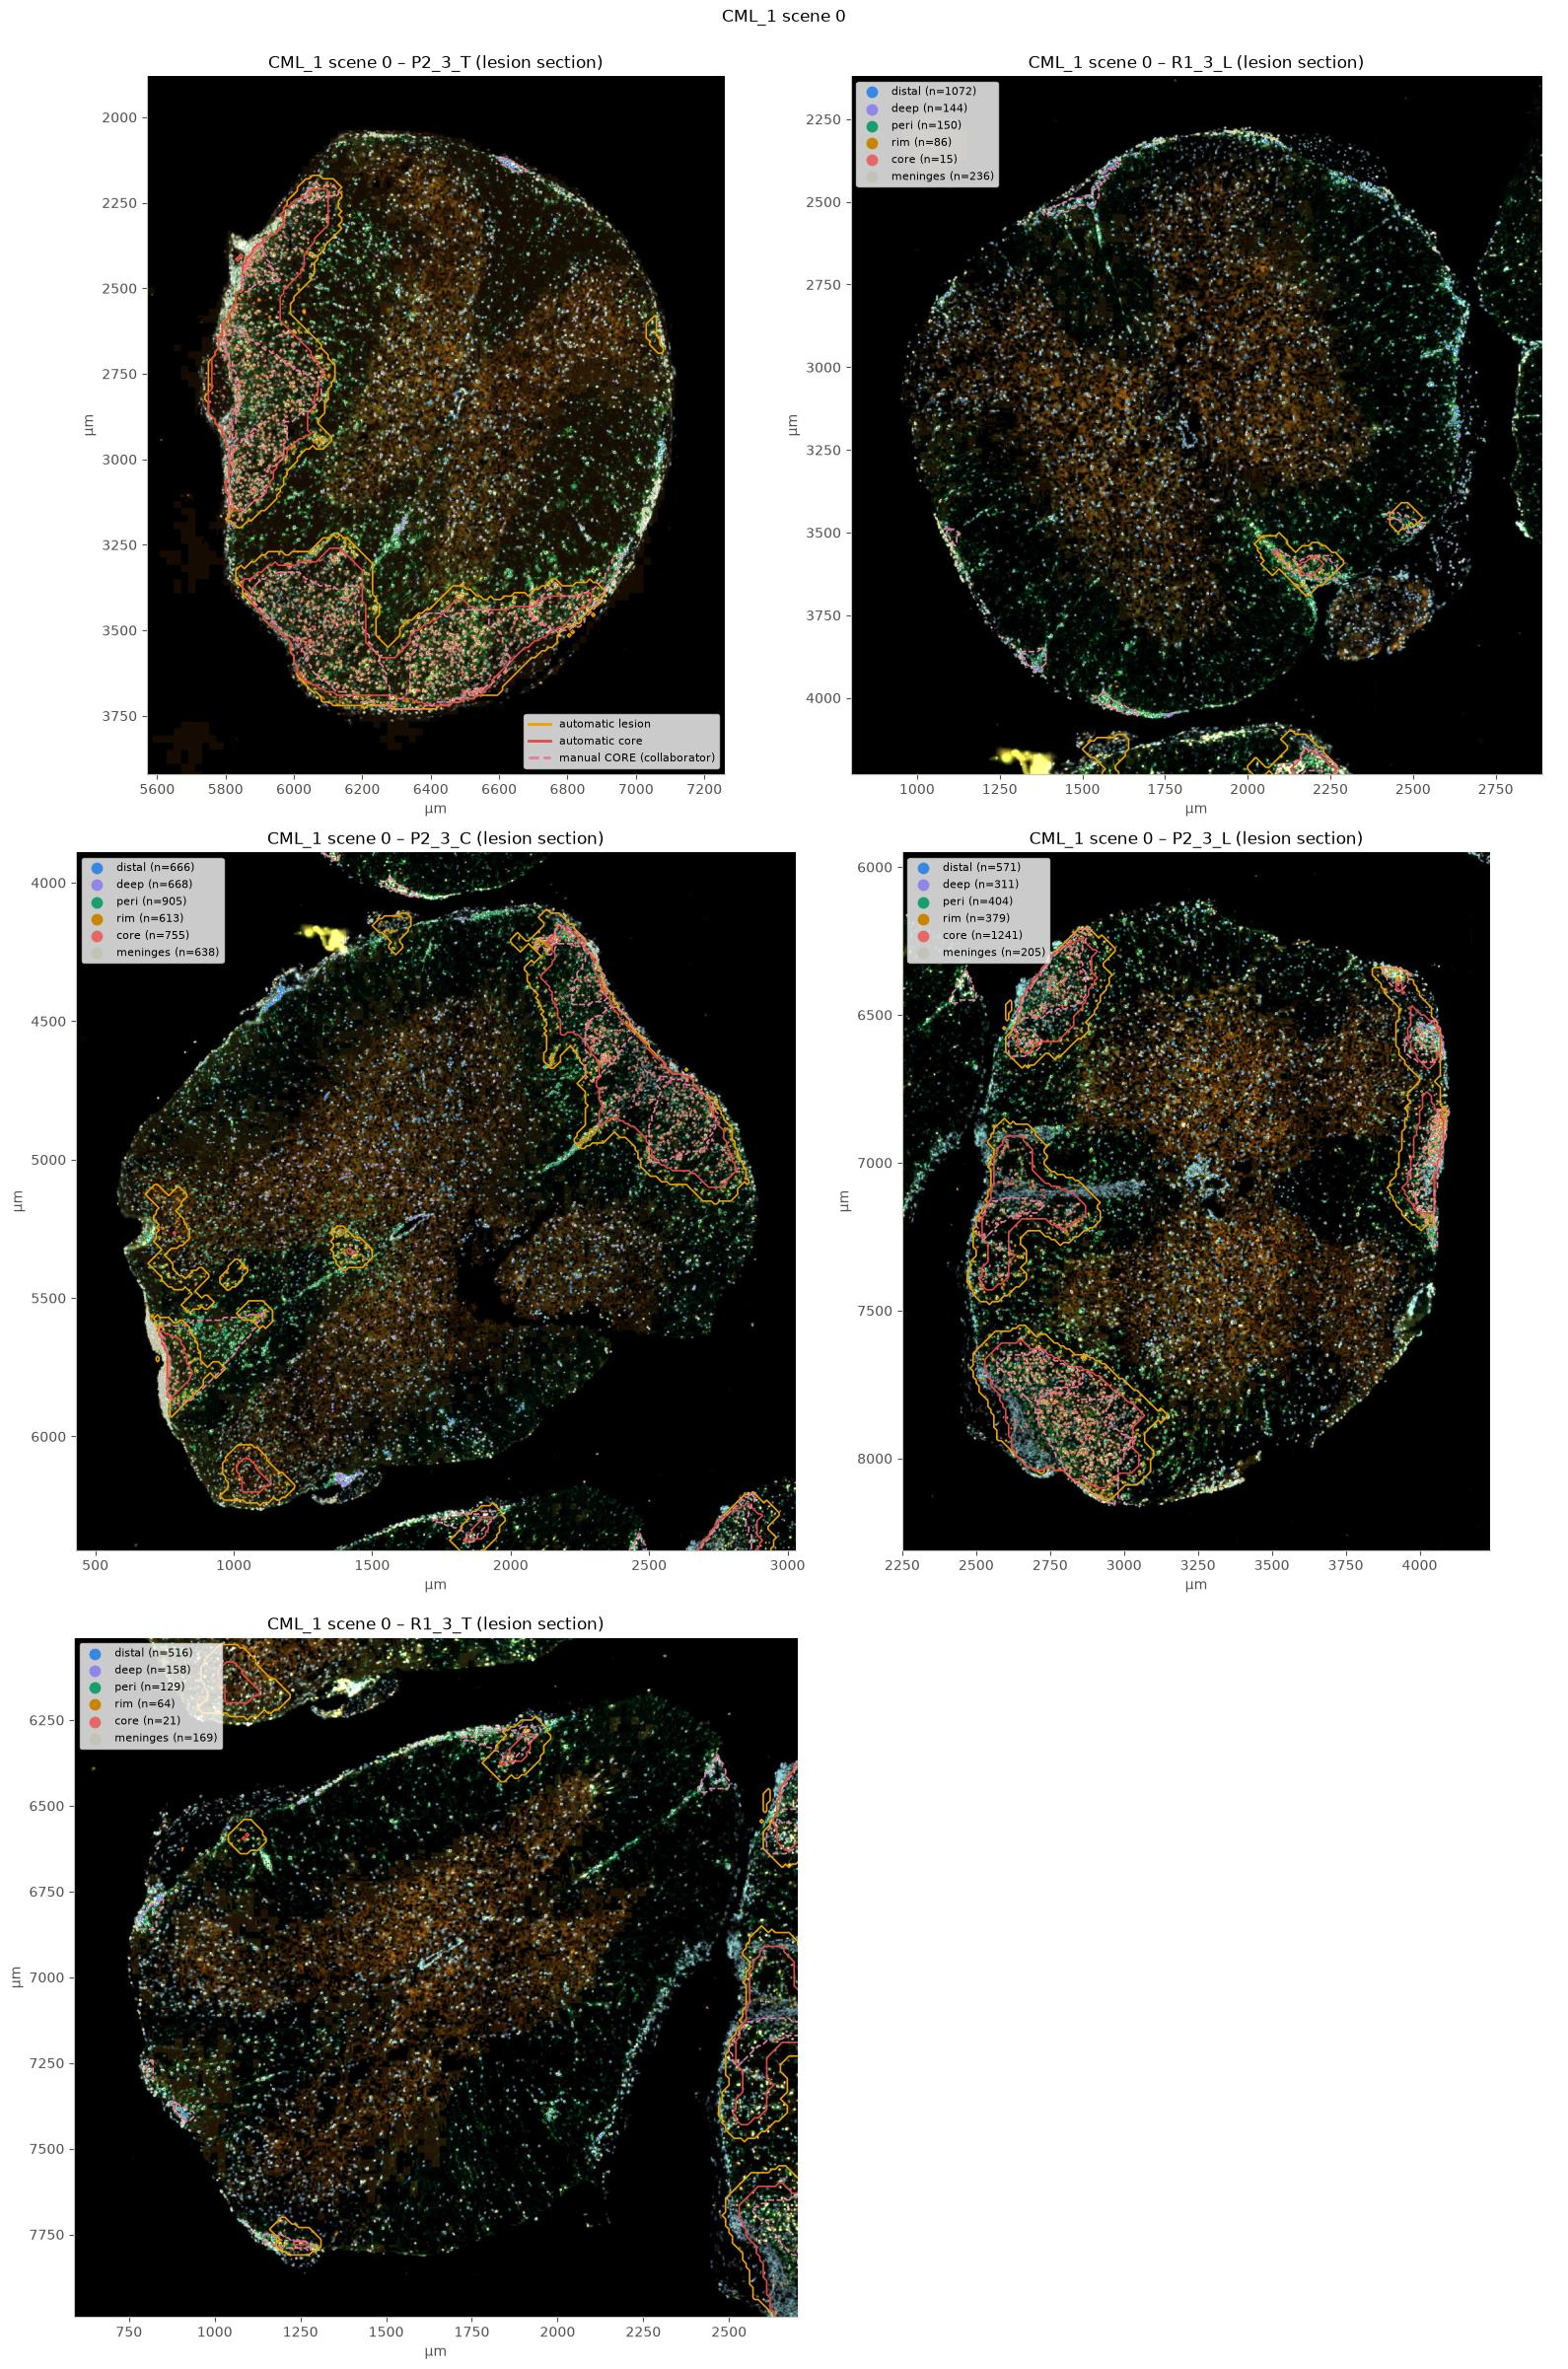

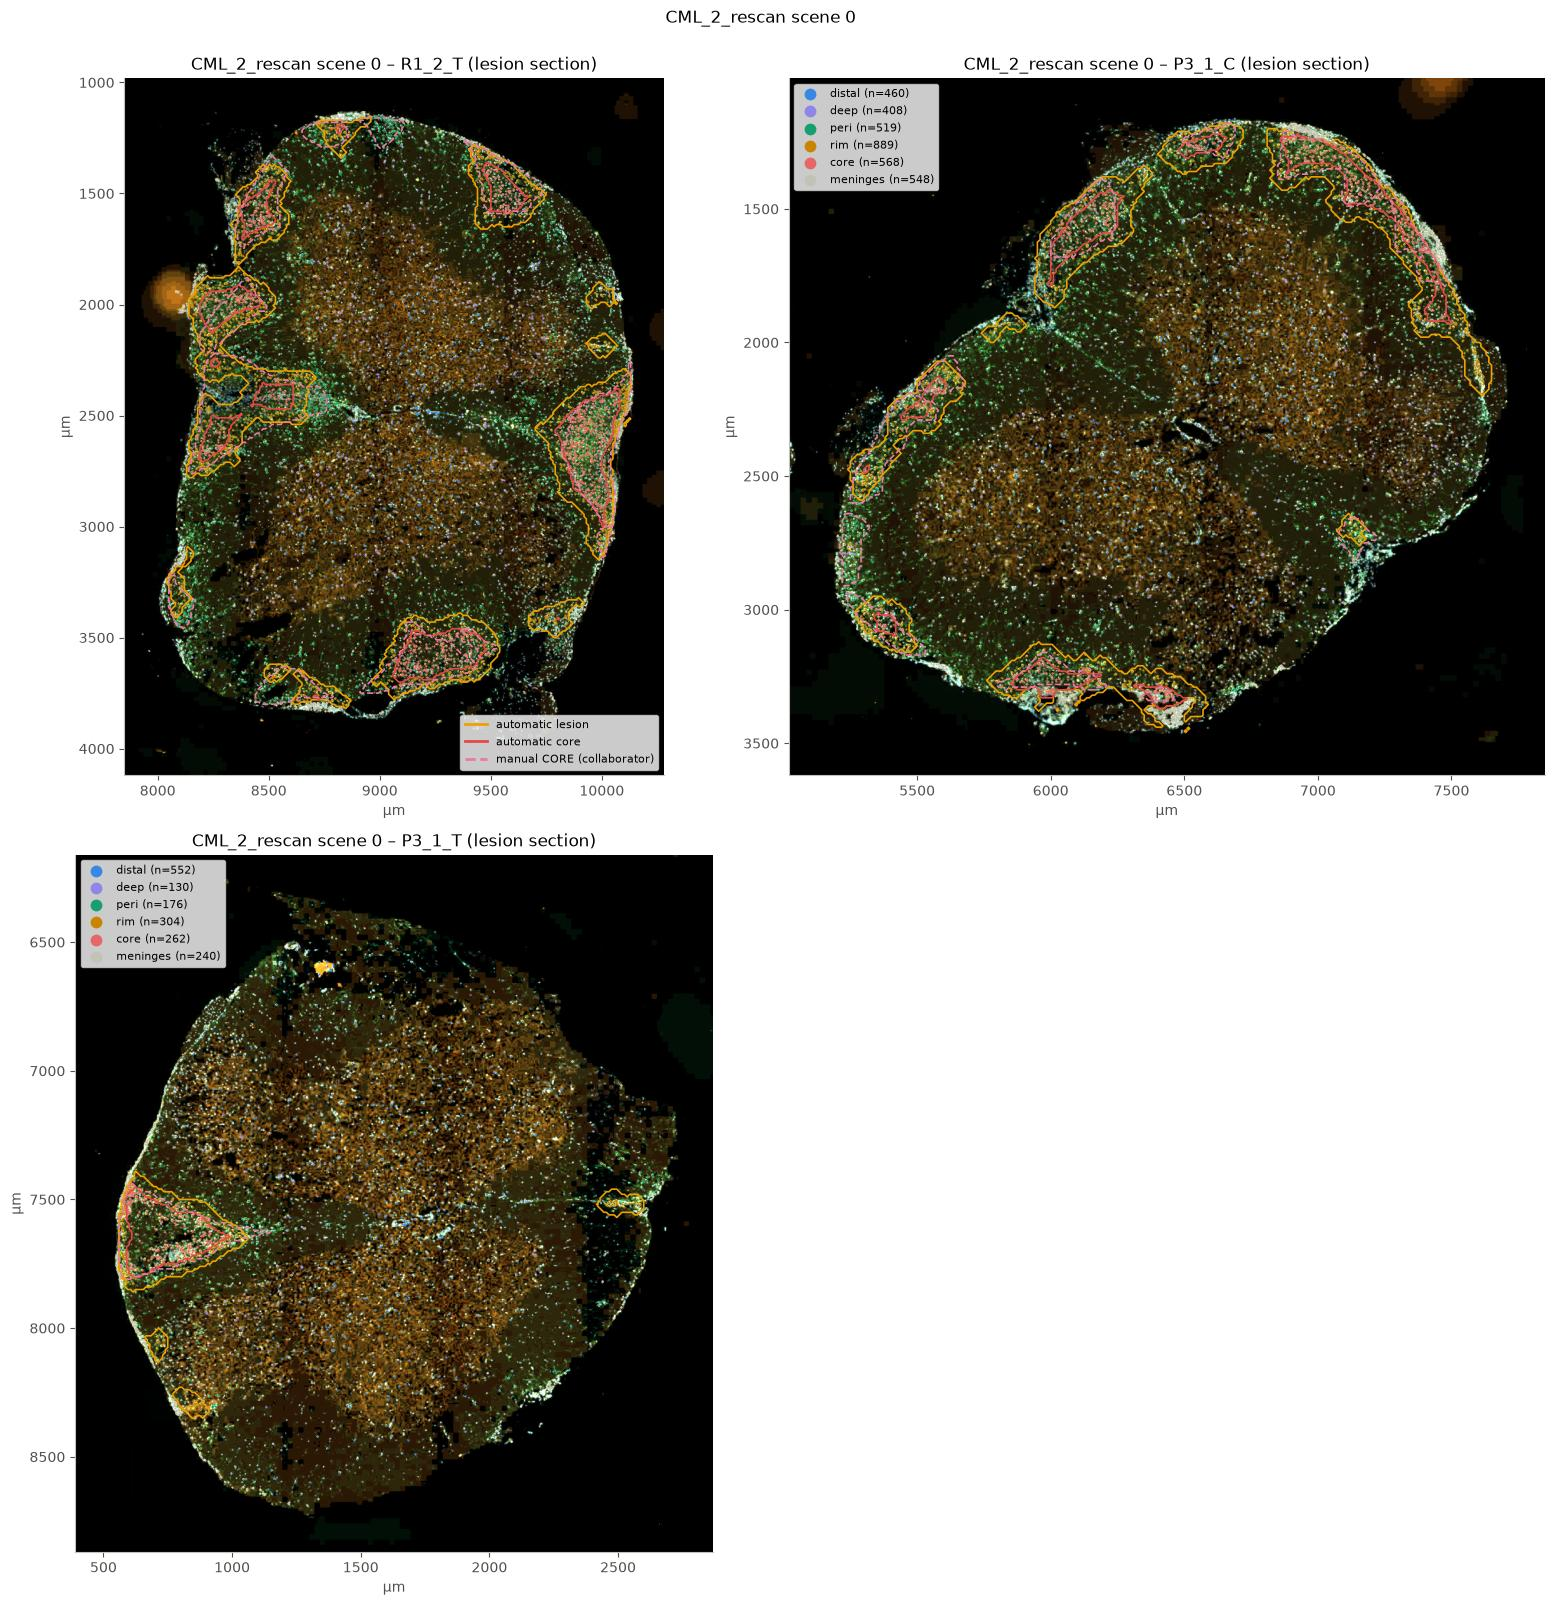

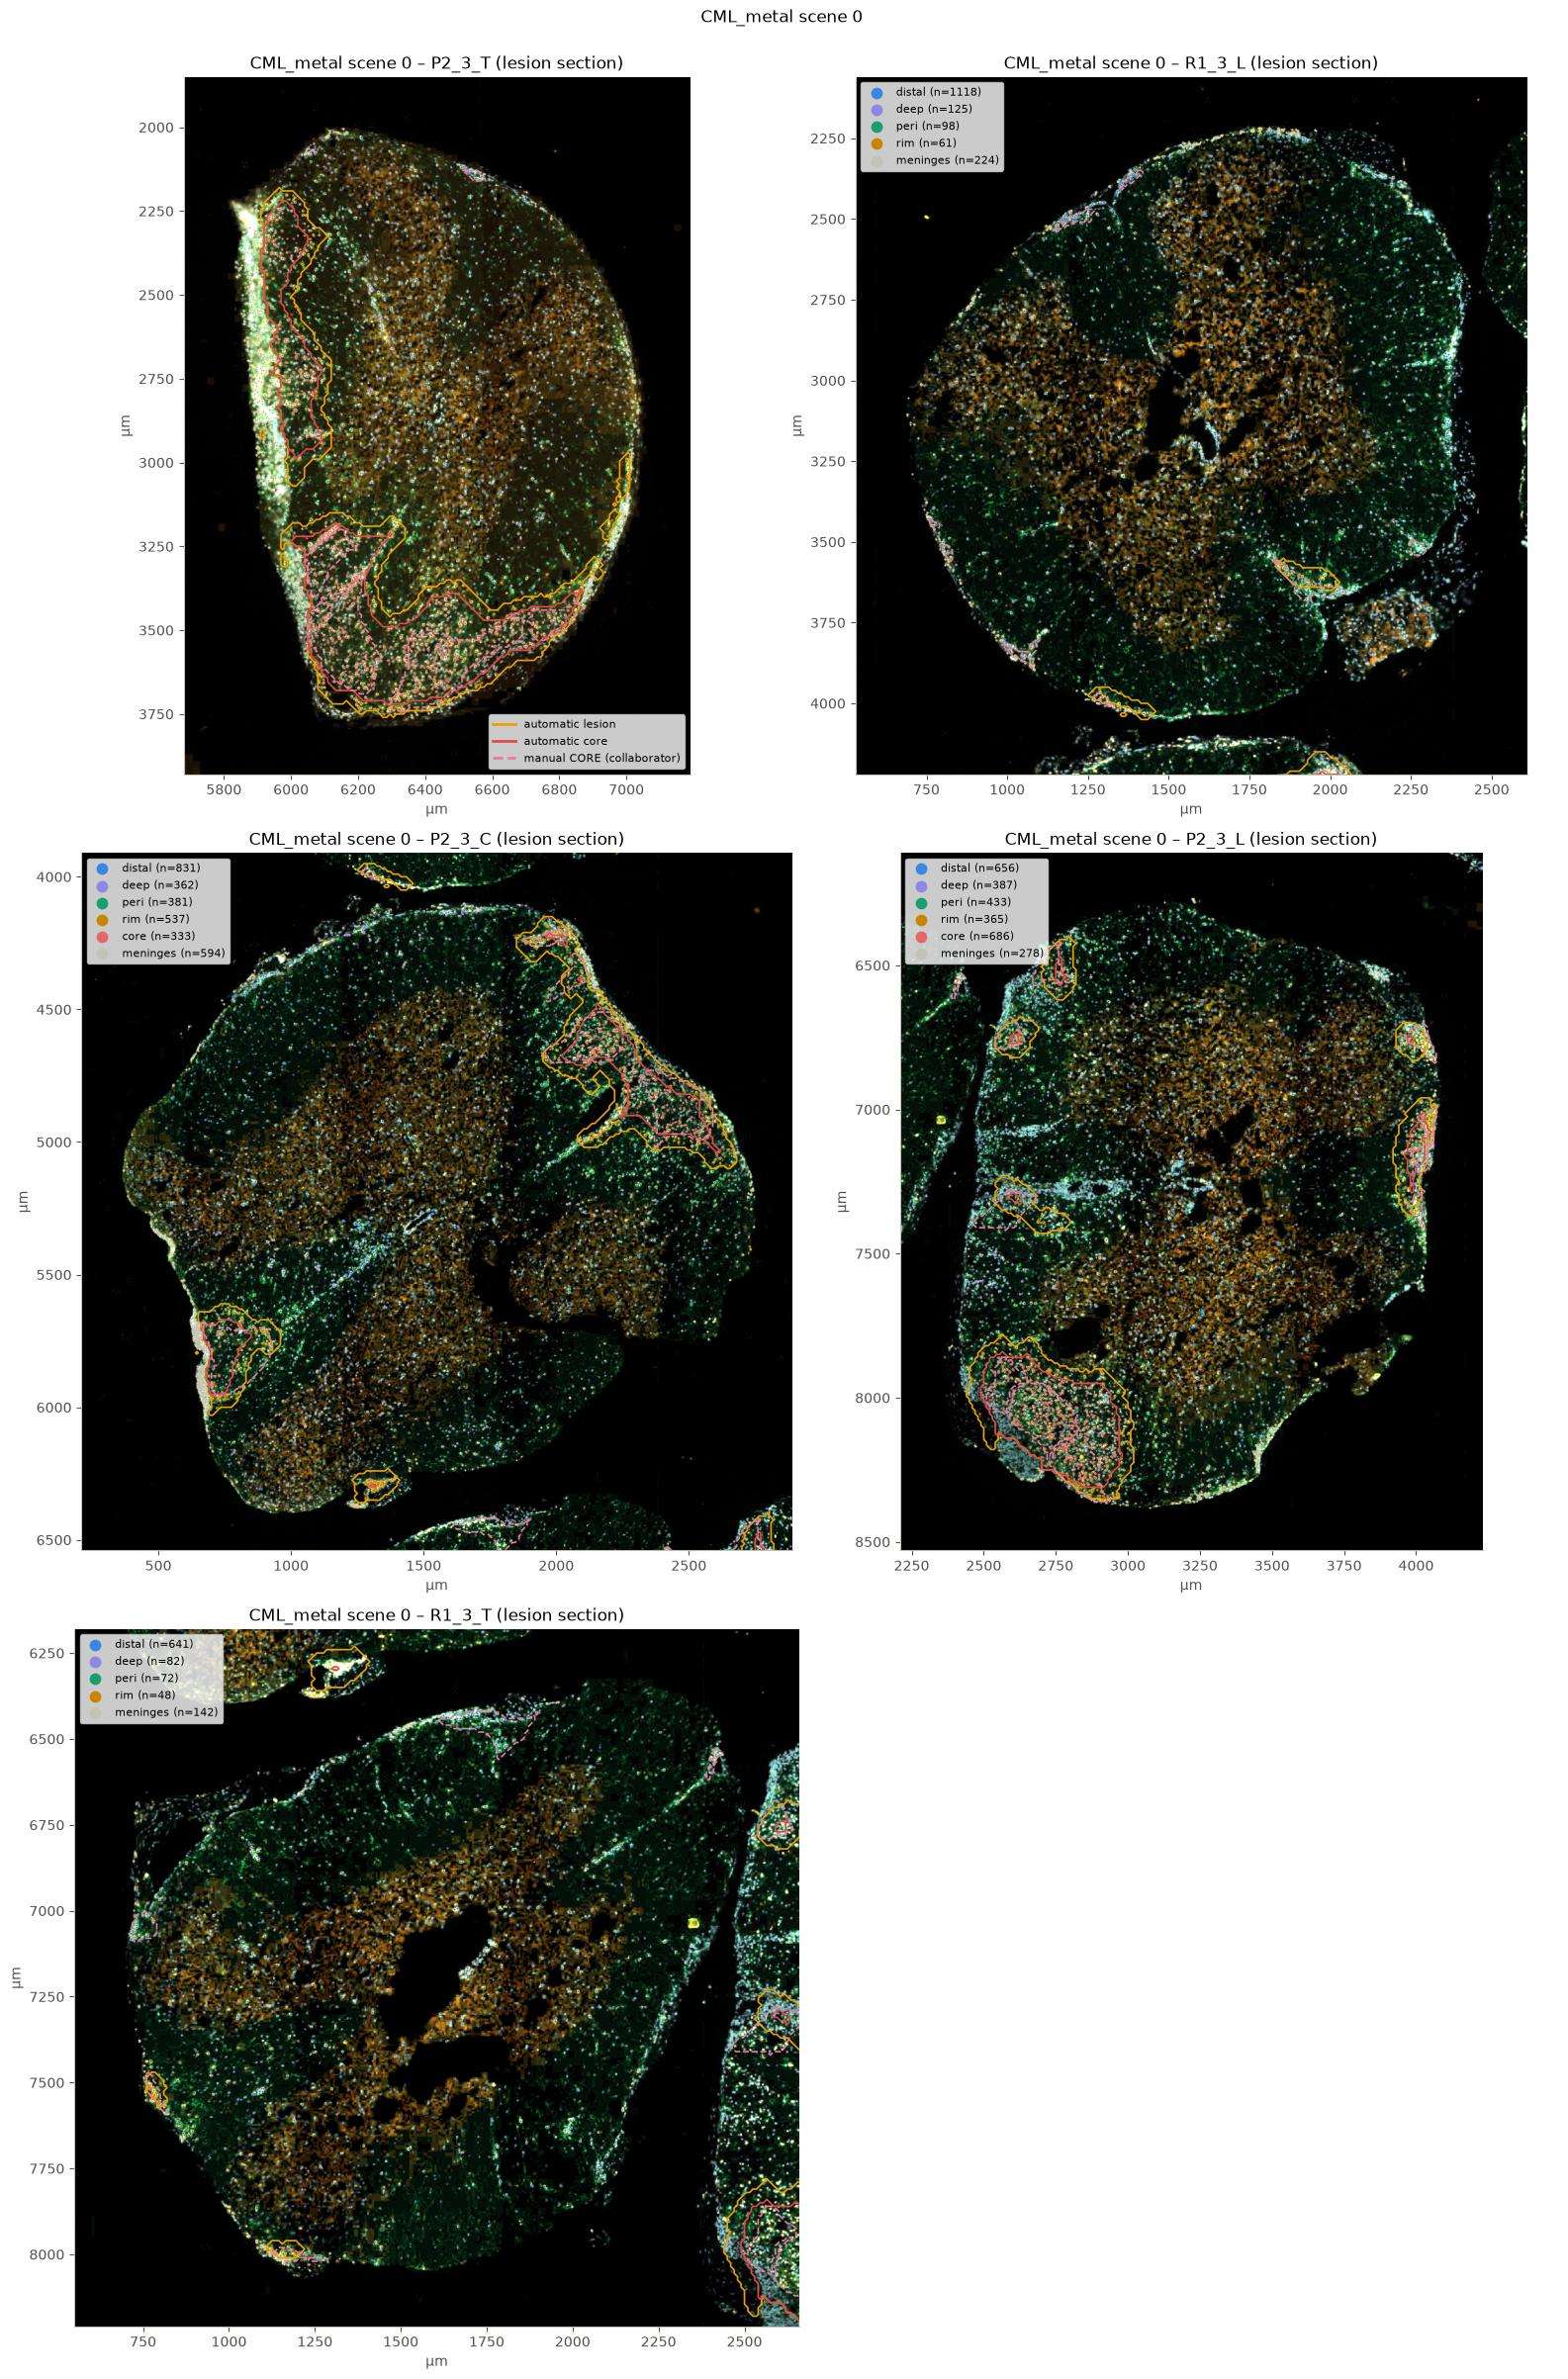

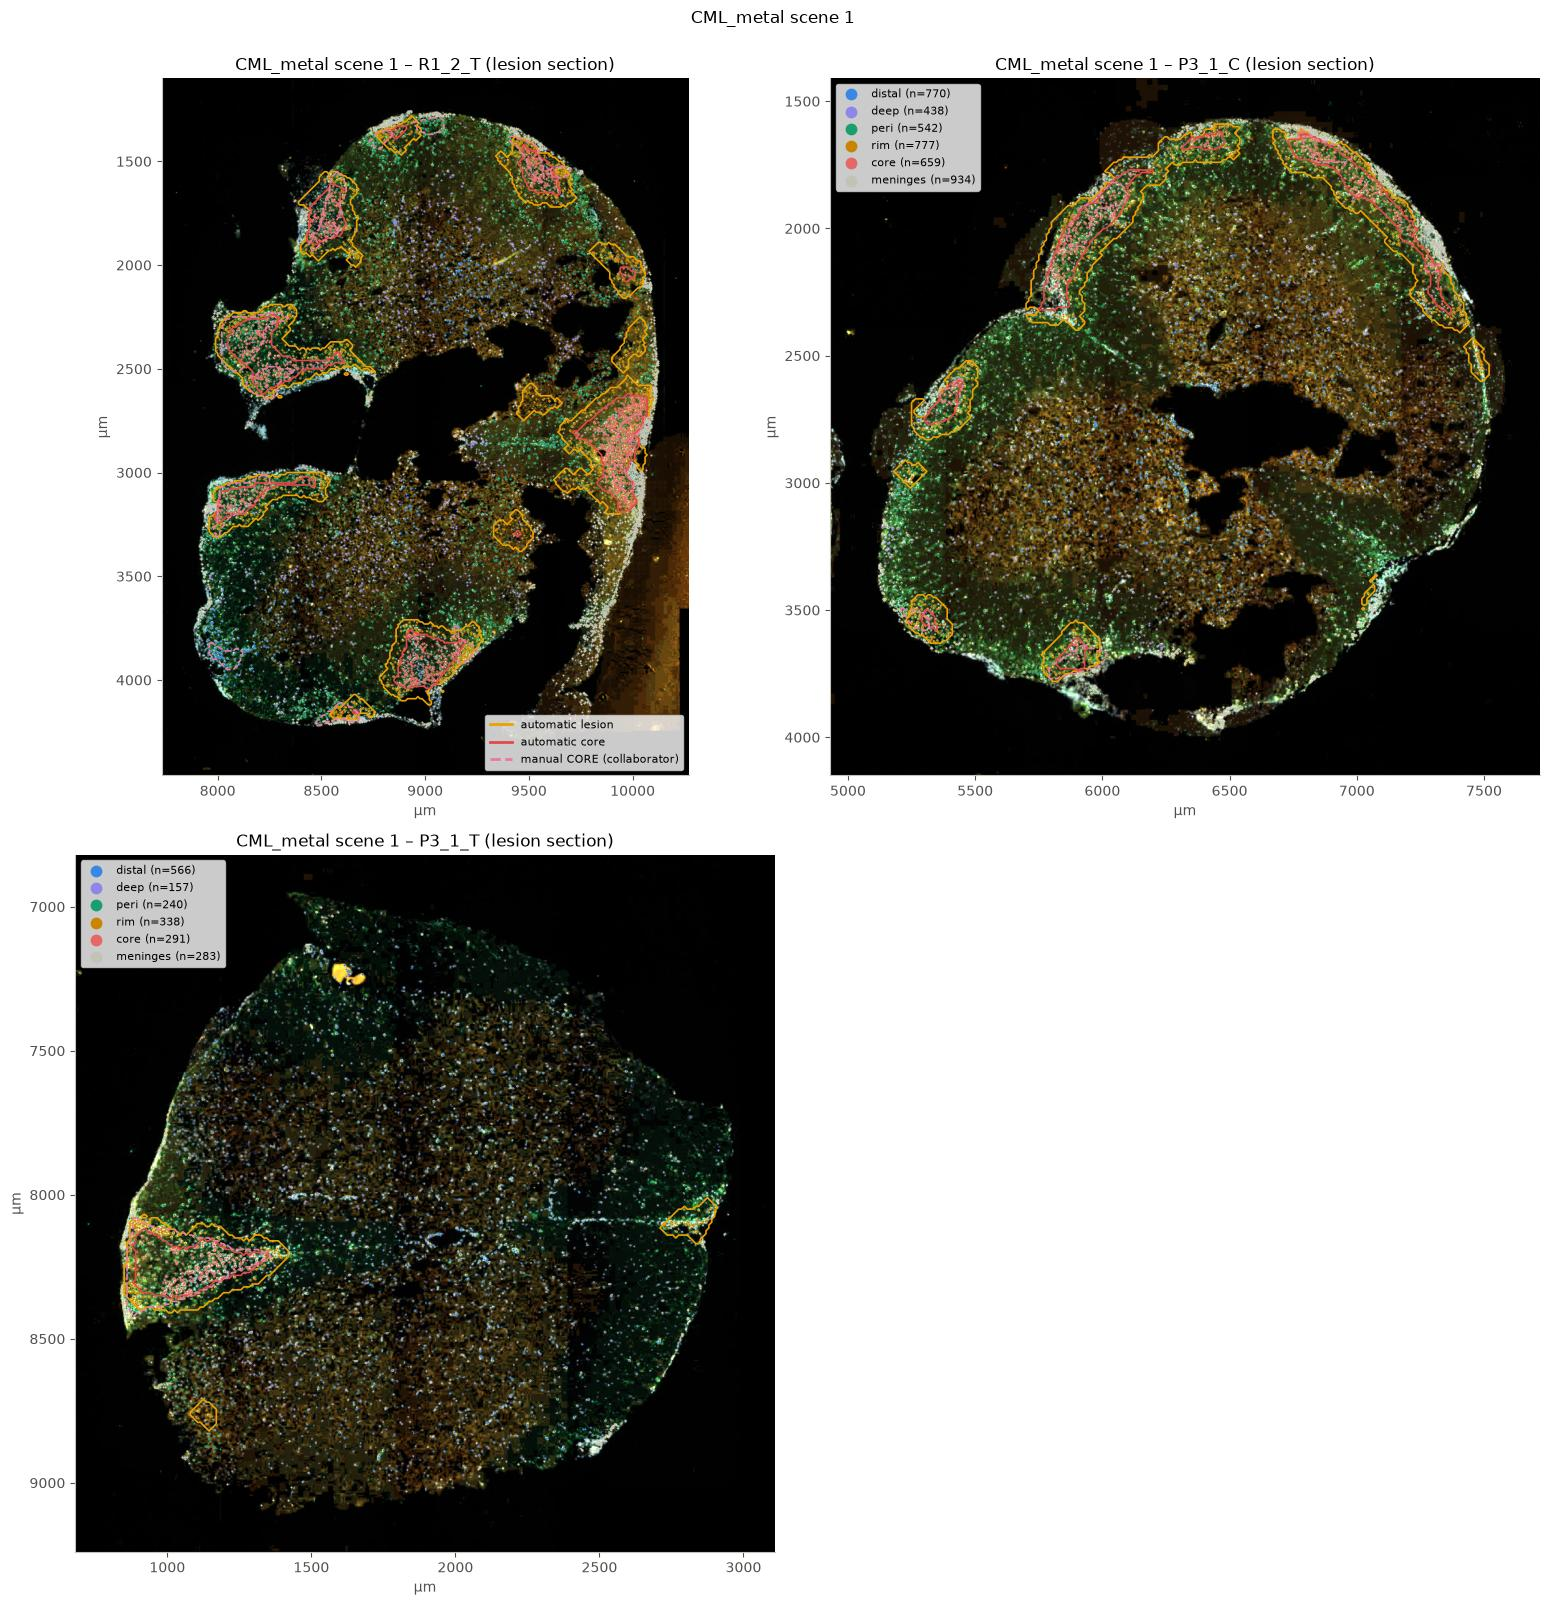

In [2]:
for r in runs:
    les_secs = r.sections[r.sections.is_lesion_section]
    n = len(les_secs)
    if n == 0:
        continue
    fig, axes = plt.subplots(int(np.ceil(n / 2)), 2, figsize=(16, 8 * int(np.ceil(n / 2))), squeeze=False)
    for ax, sid in zip(axes.ravel(), les_secs.section_id):
        R.plot_section(r, int(sid), ax=ax, scale=0.2)
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    R.outline_legend(axes.ravel()[0])
    fig.suptitle(r.name, y=1.0)
    plt.tight_layout(); plt.show()

## Every lesion at full resolution (largest first)

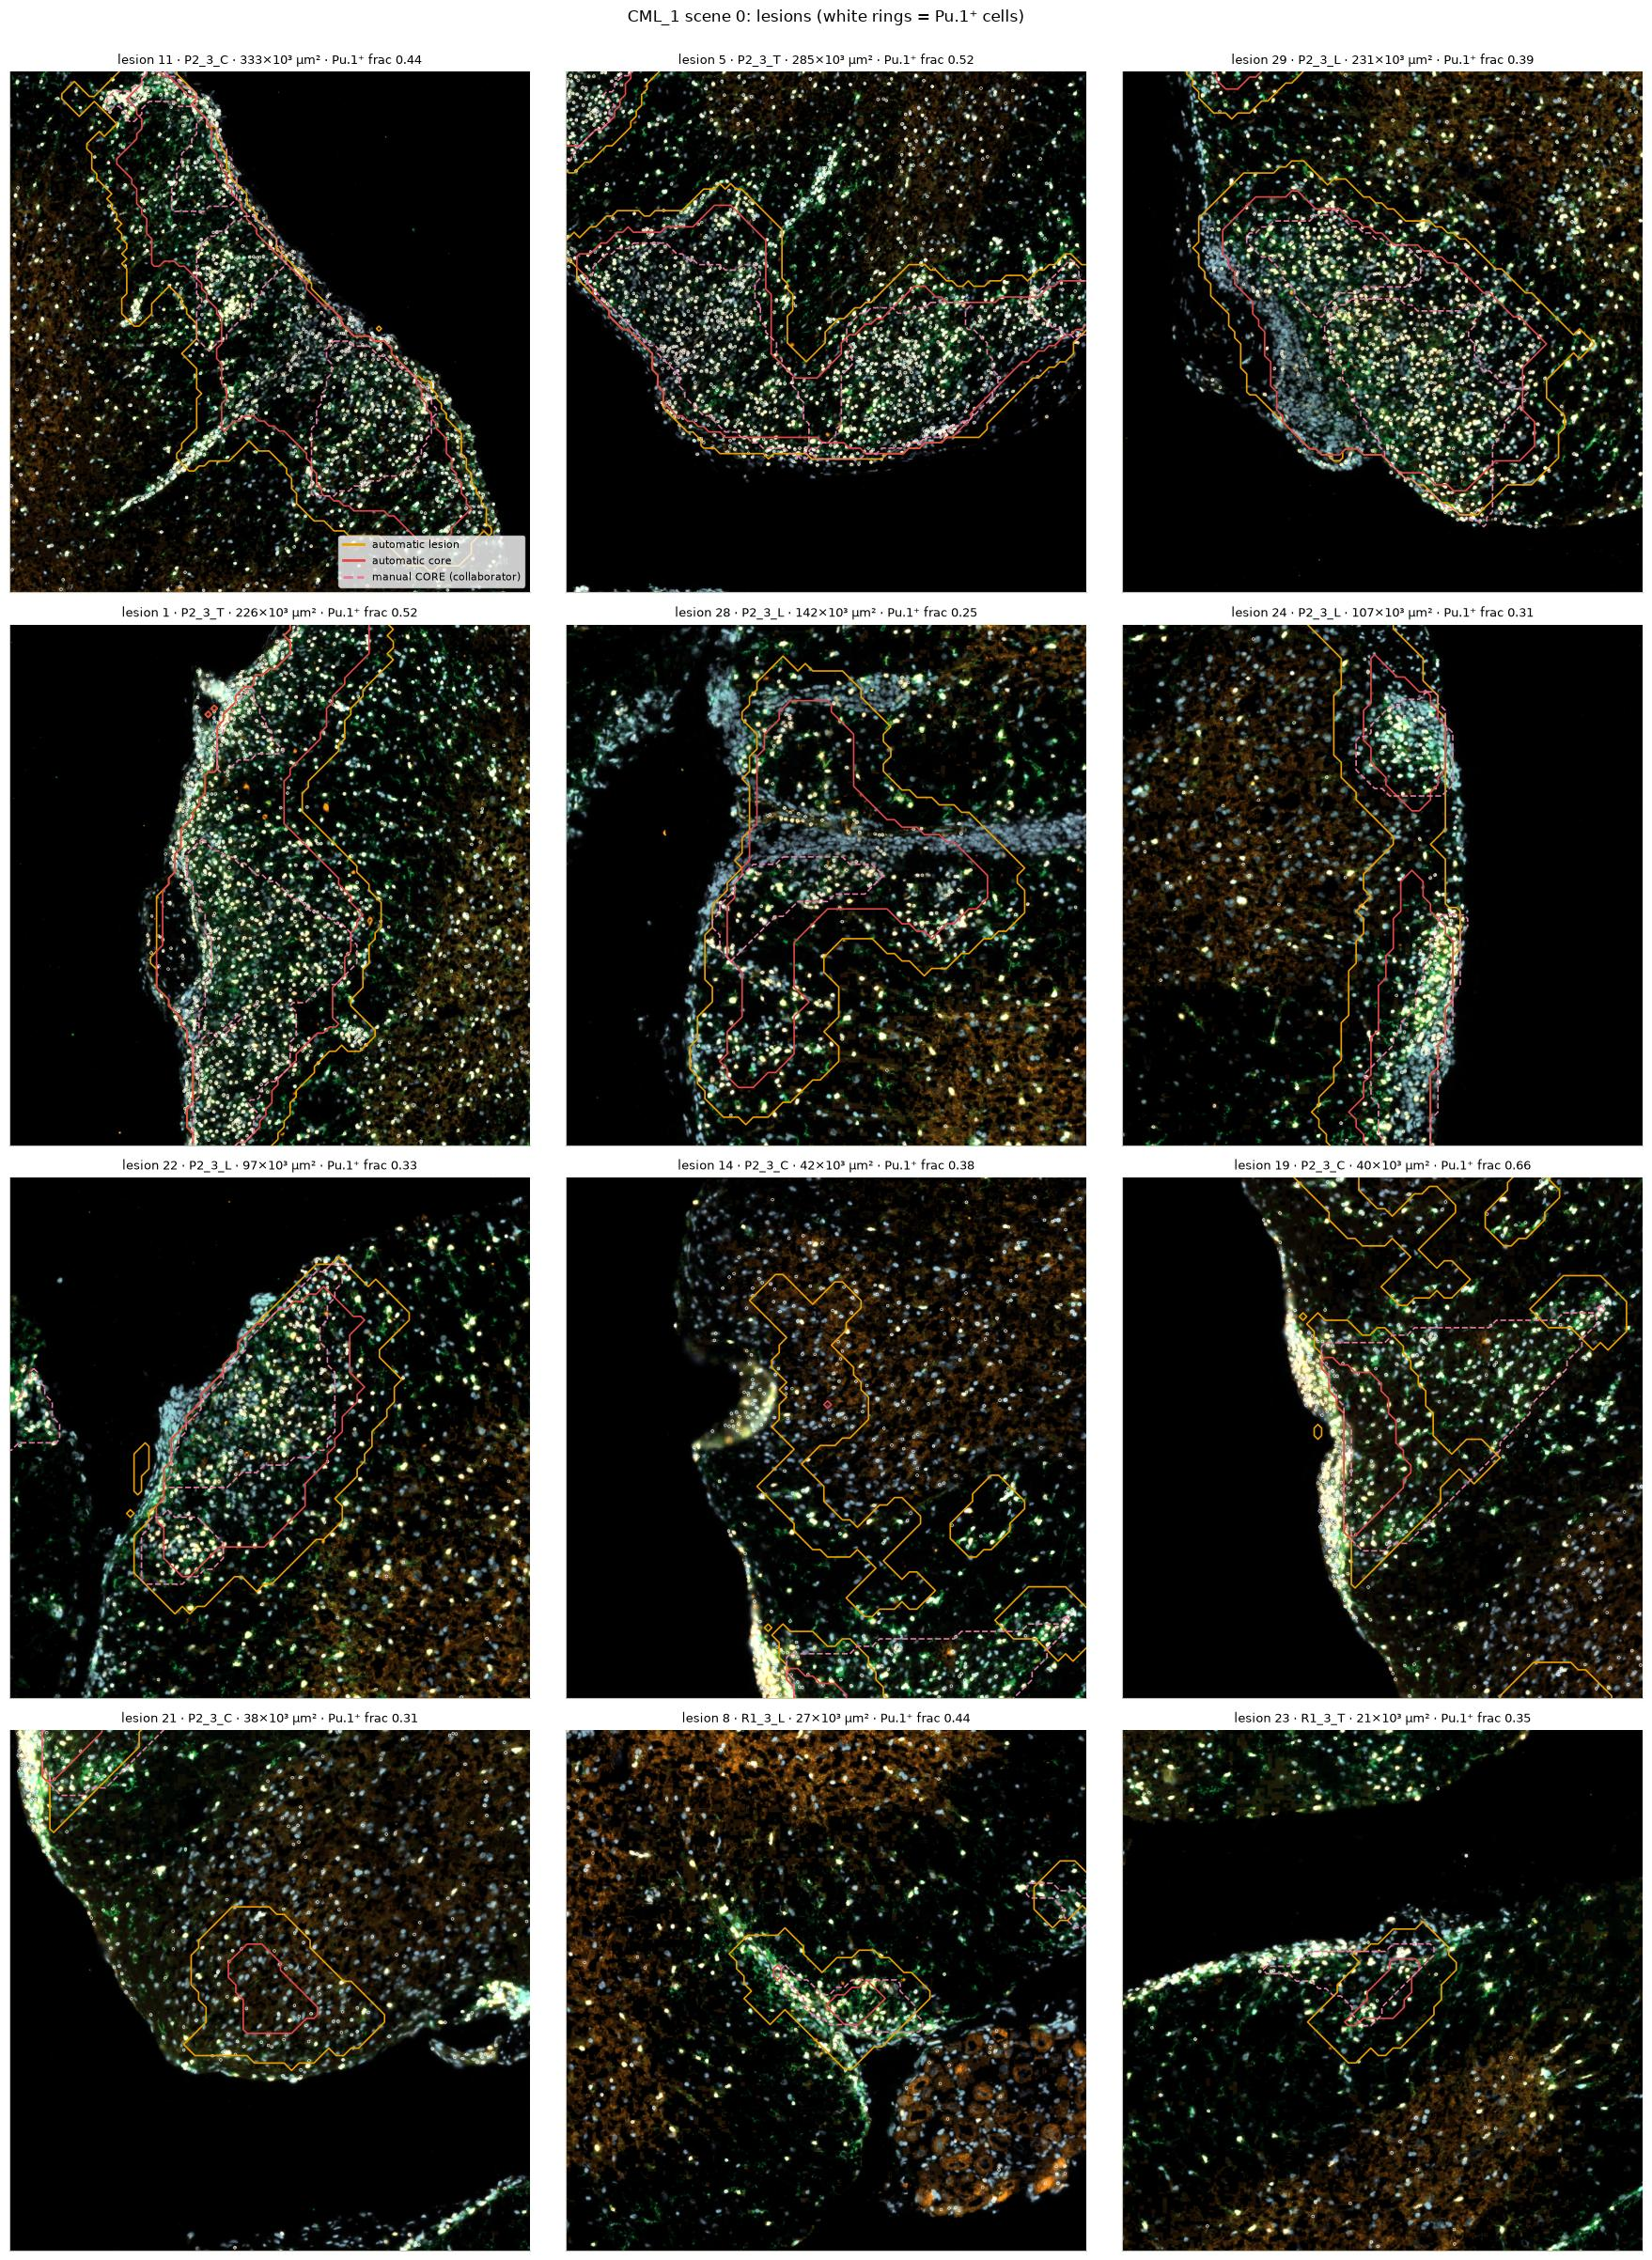

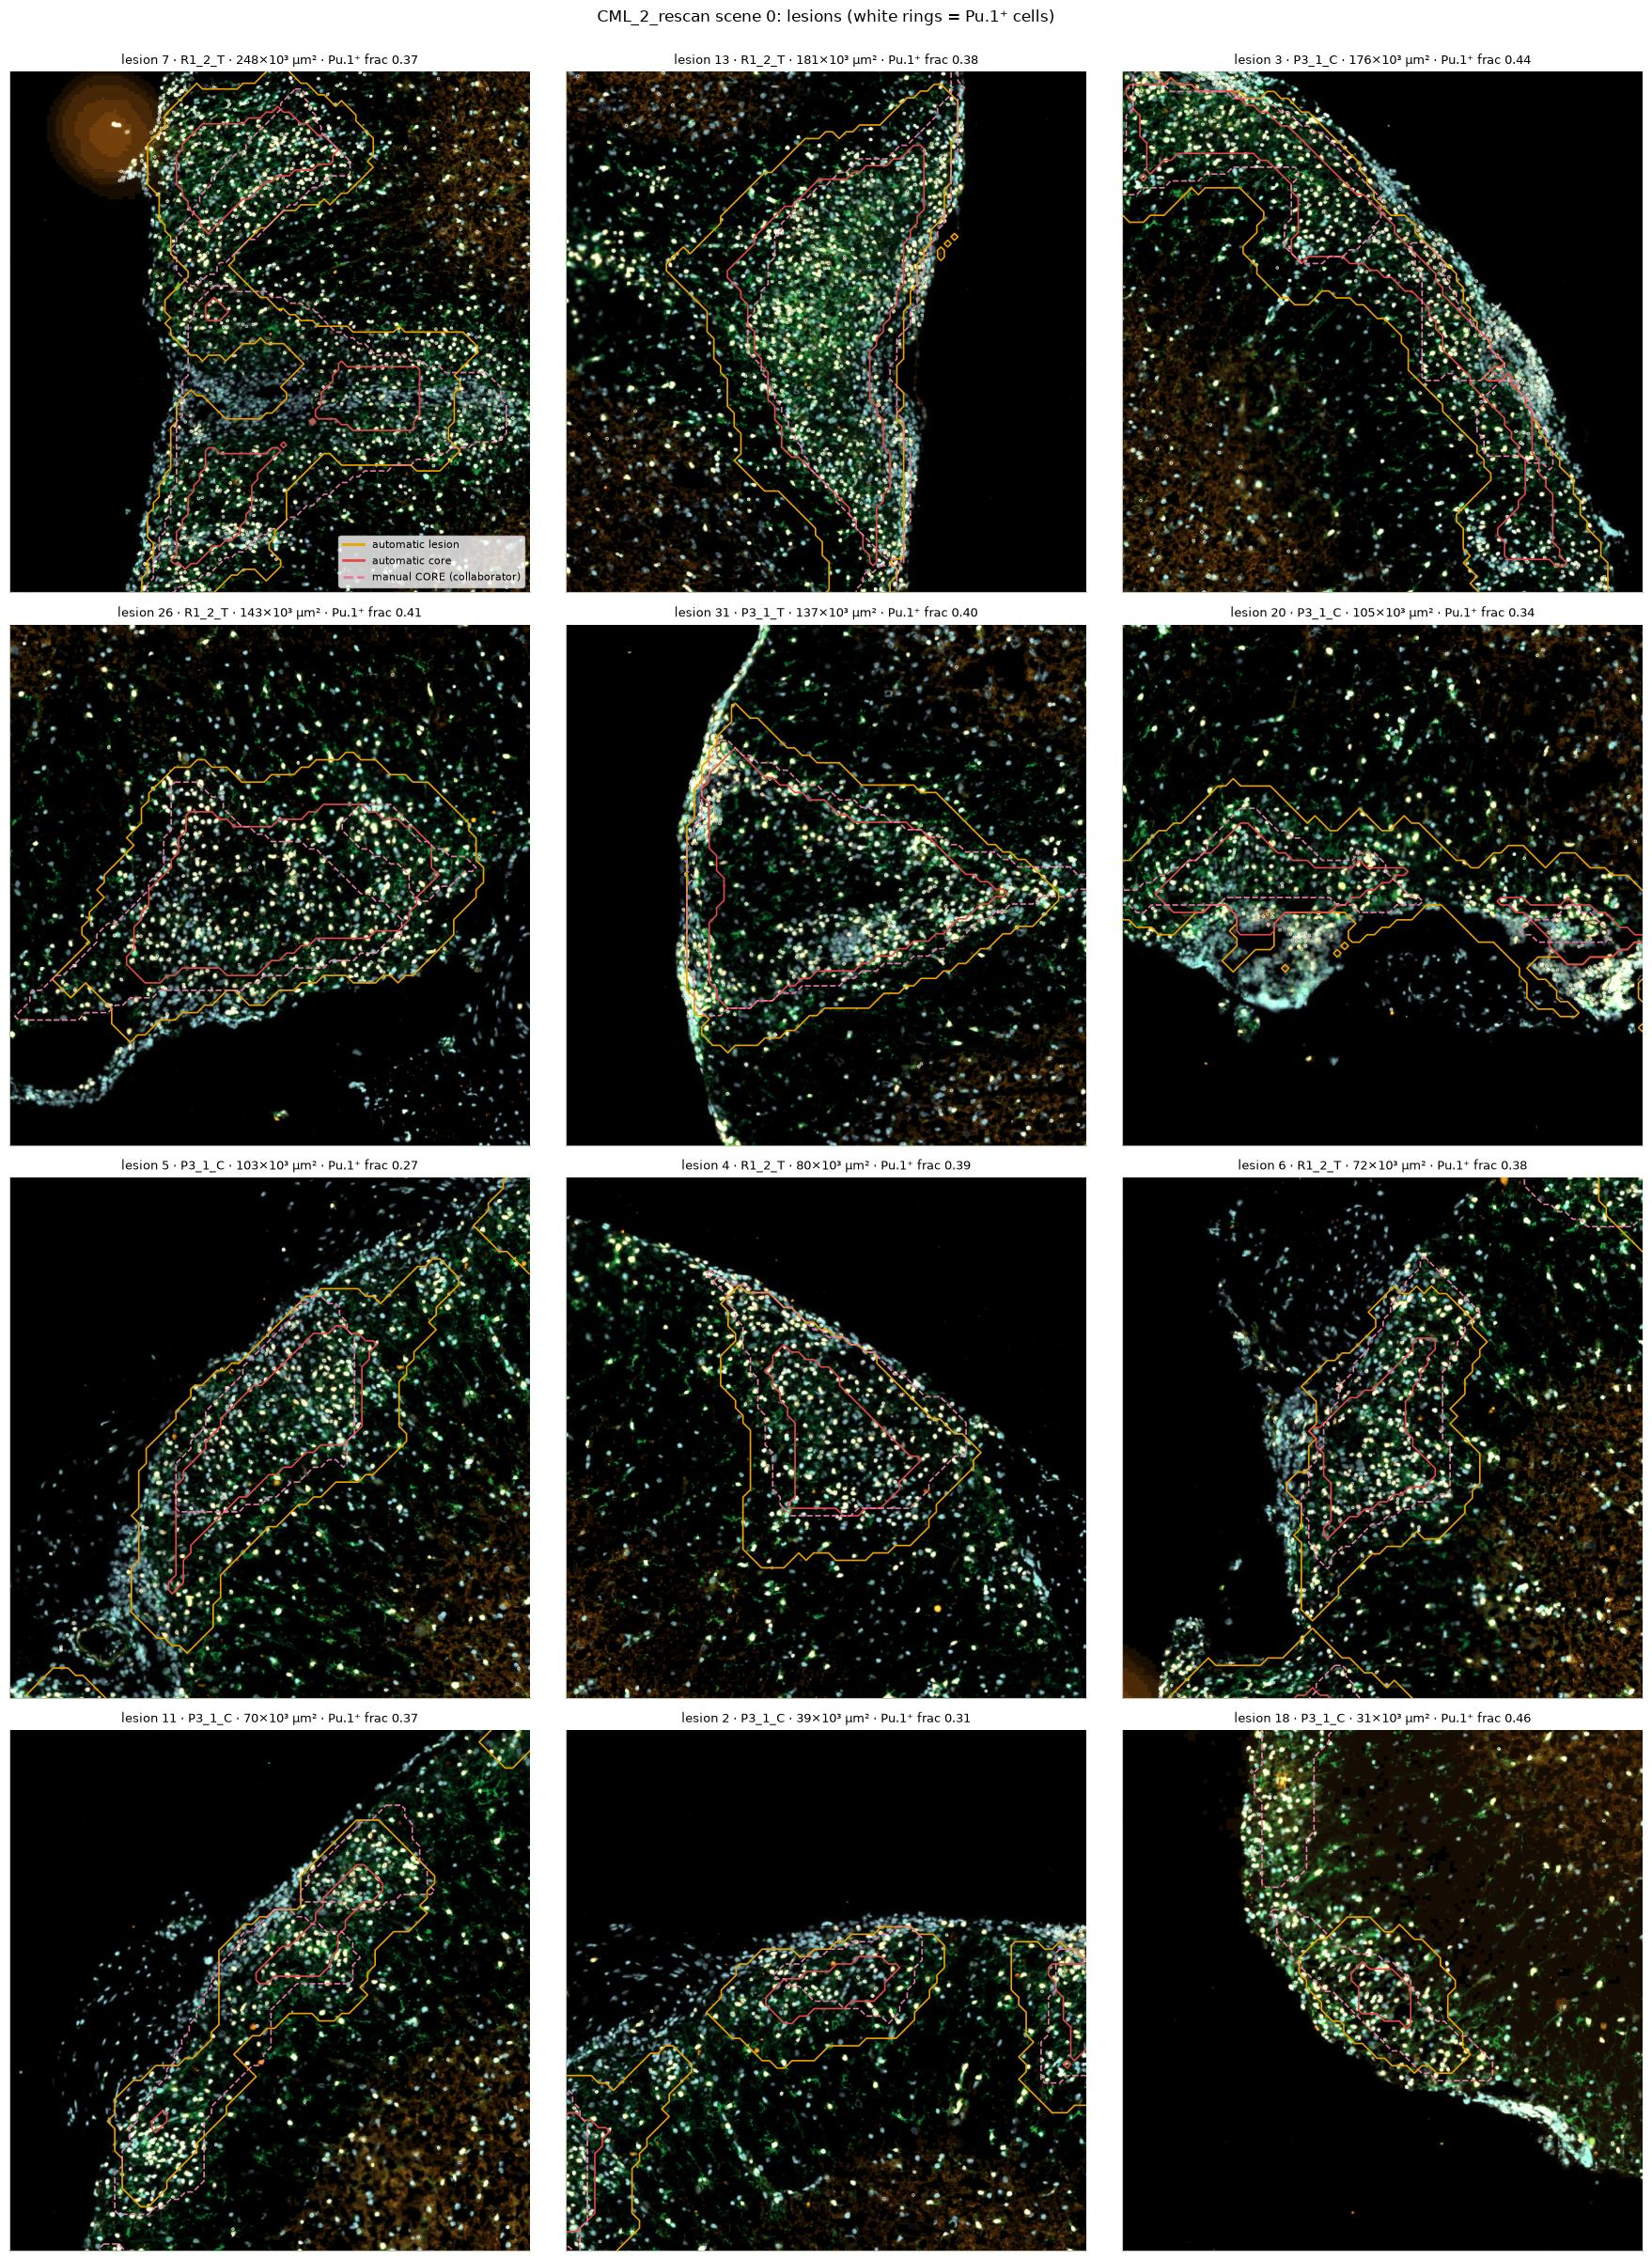

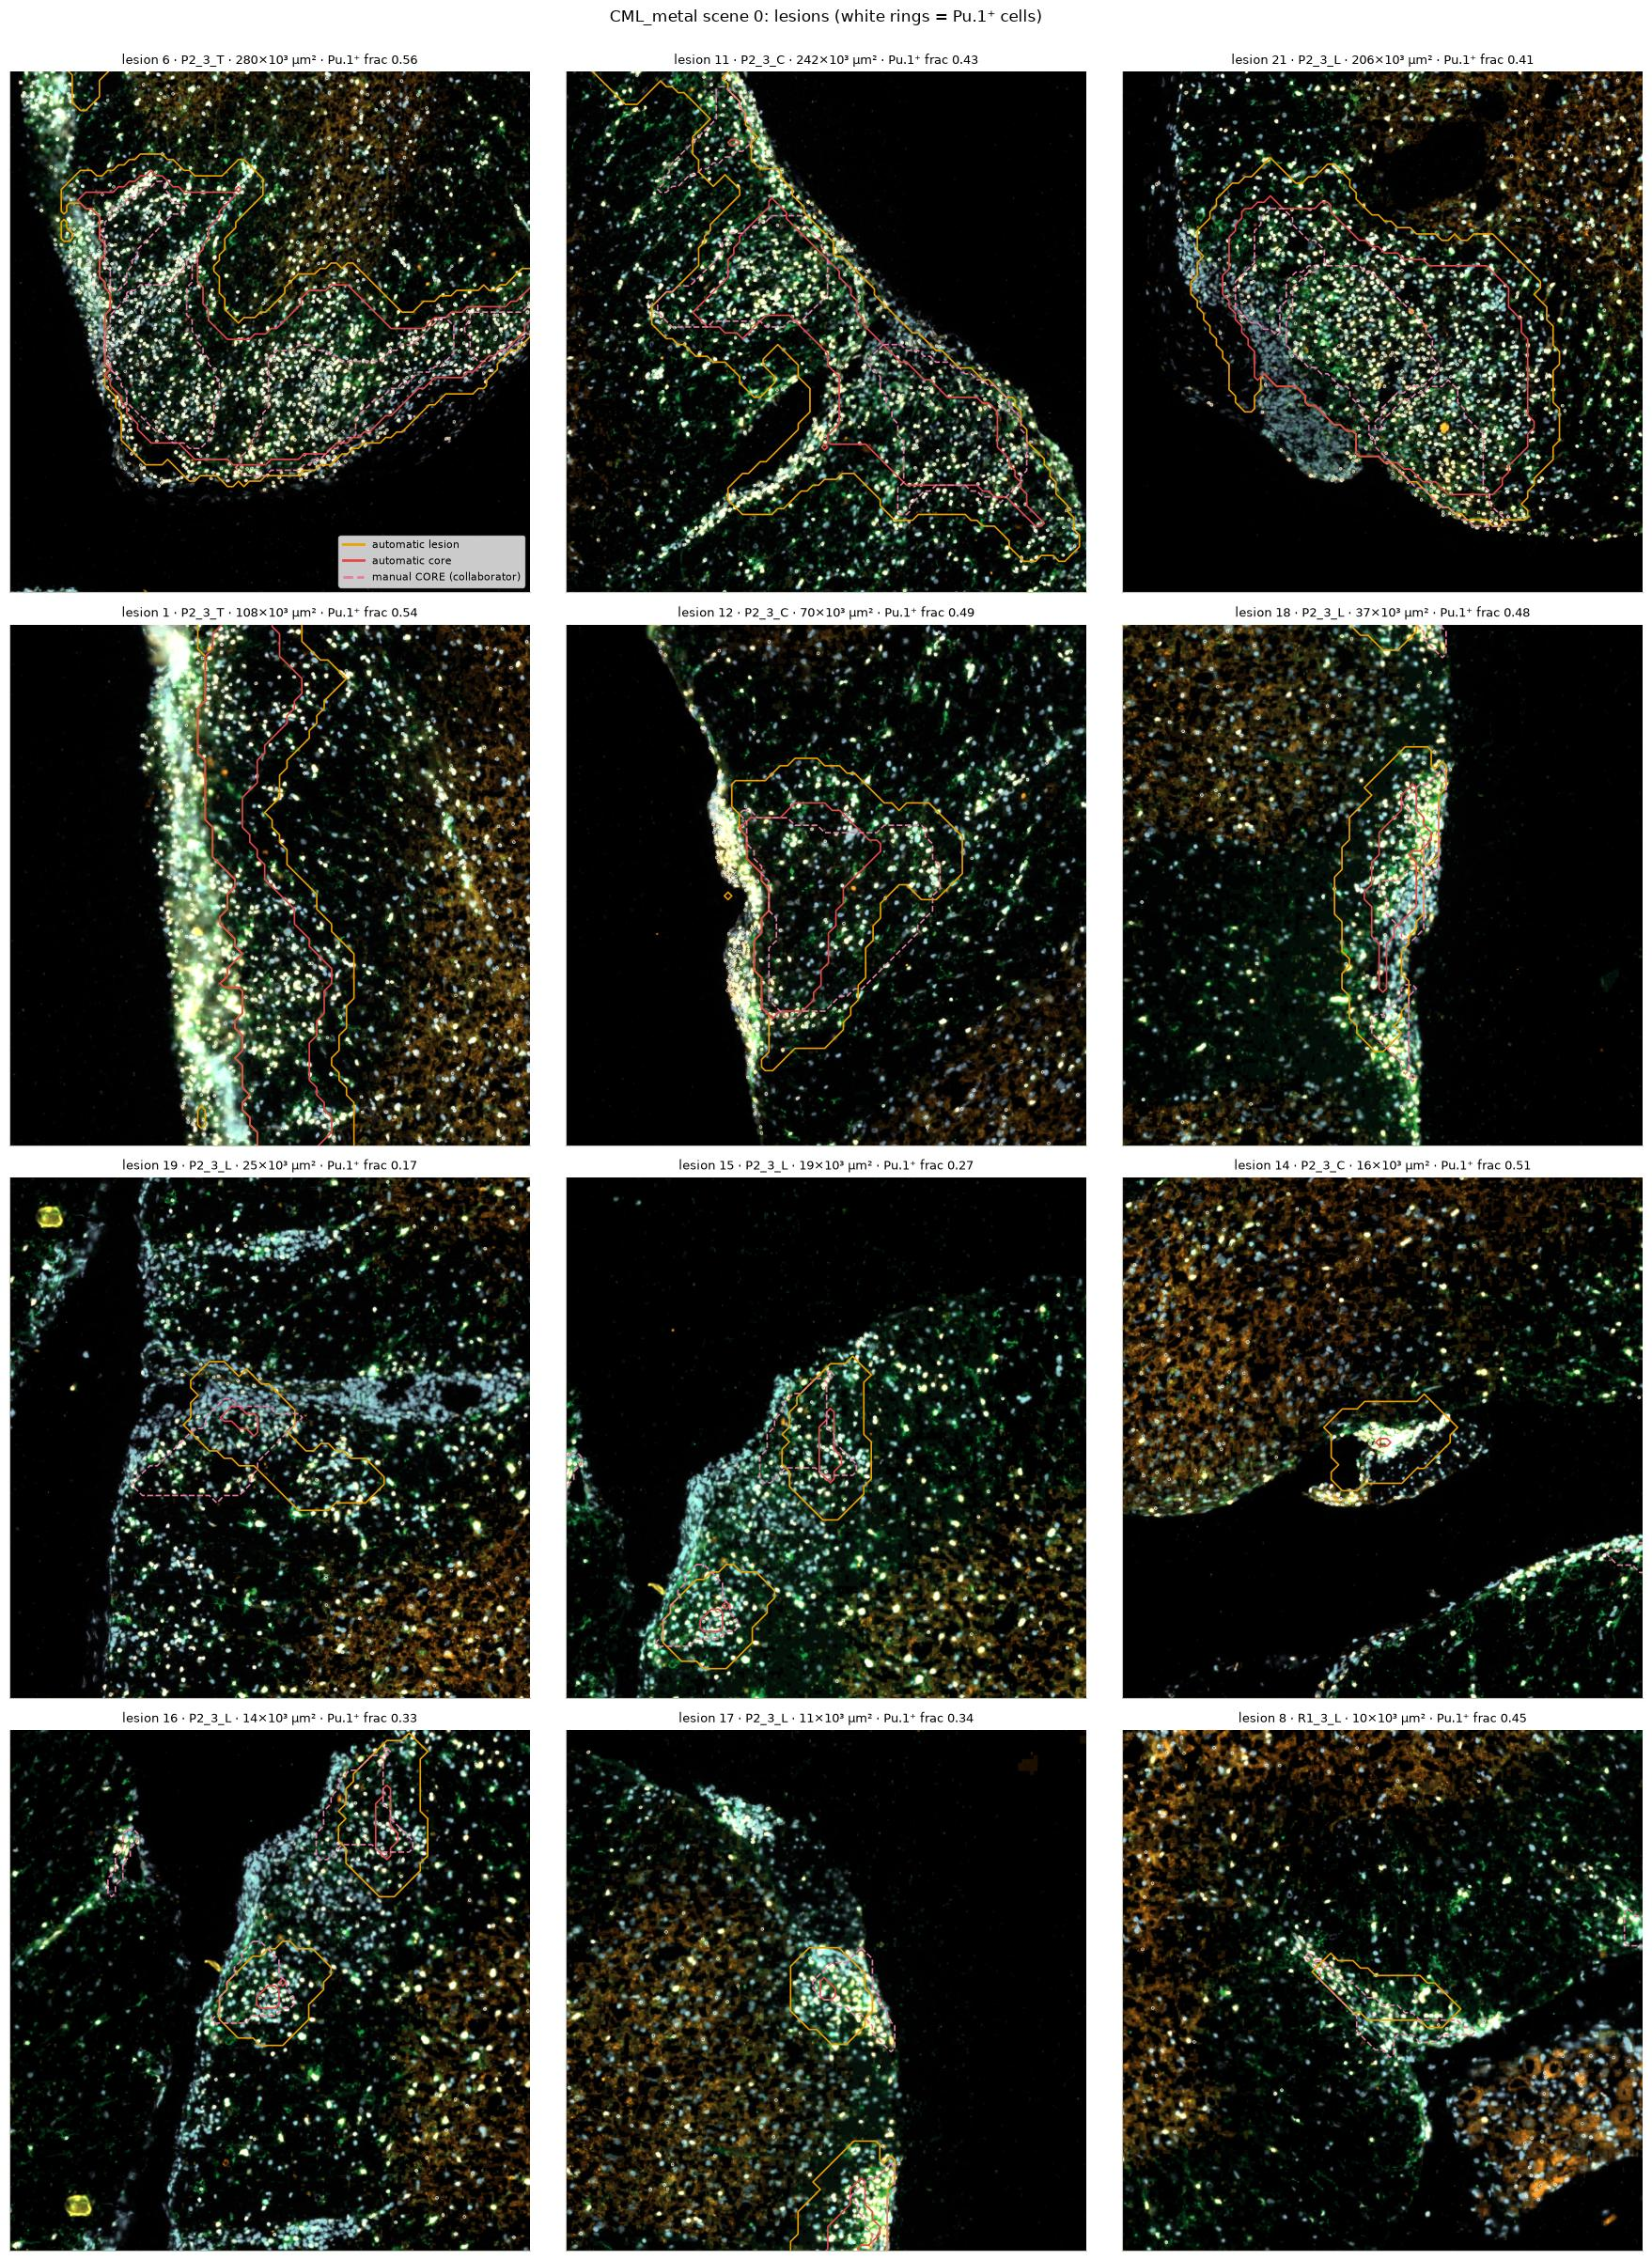

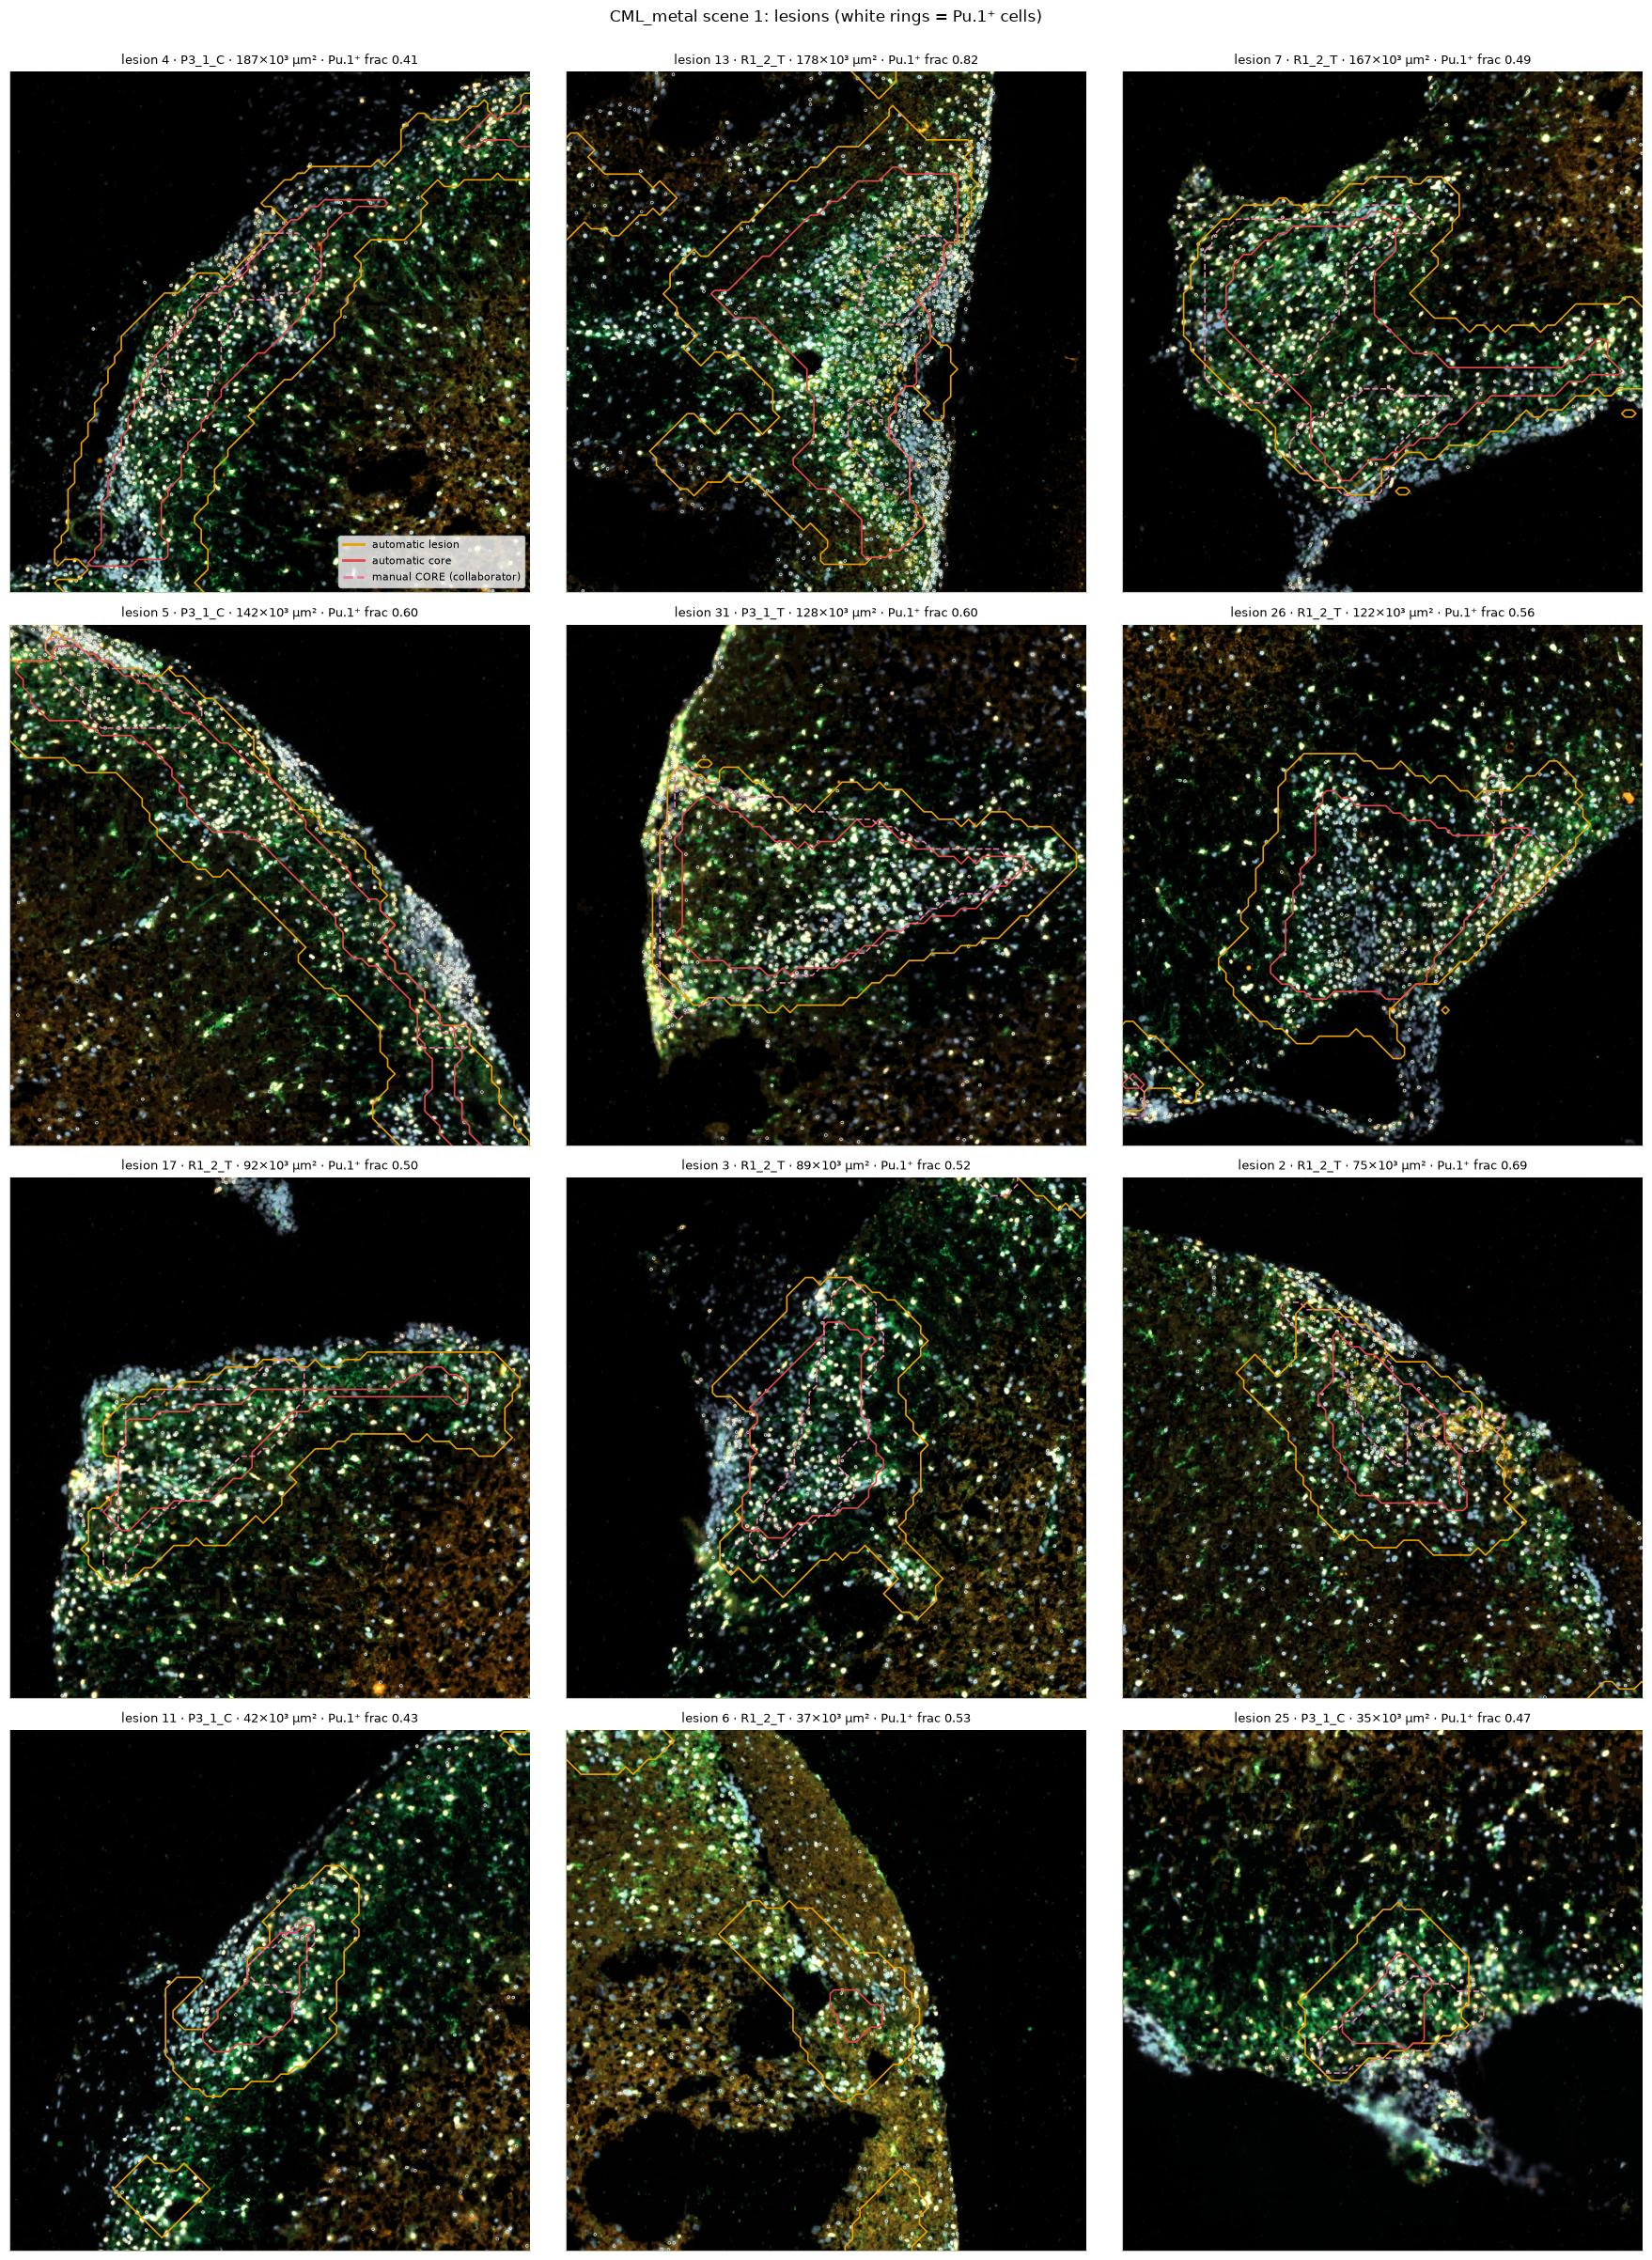

In [3]:
for r in runs:
    fig = R.lesion_gallery(r, max_n=12, ncols=3)
    plt.show()

## Control sections (should stay empty)

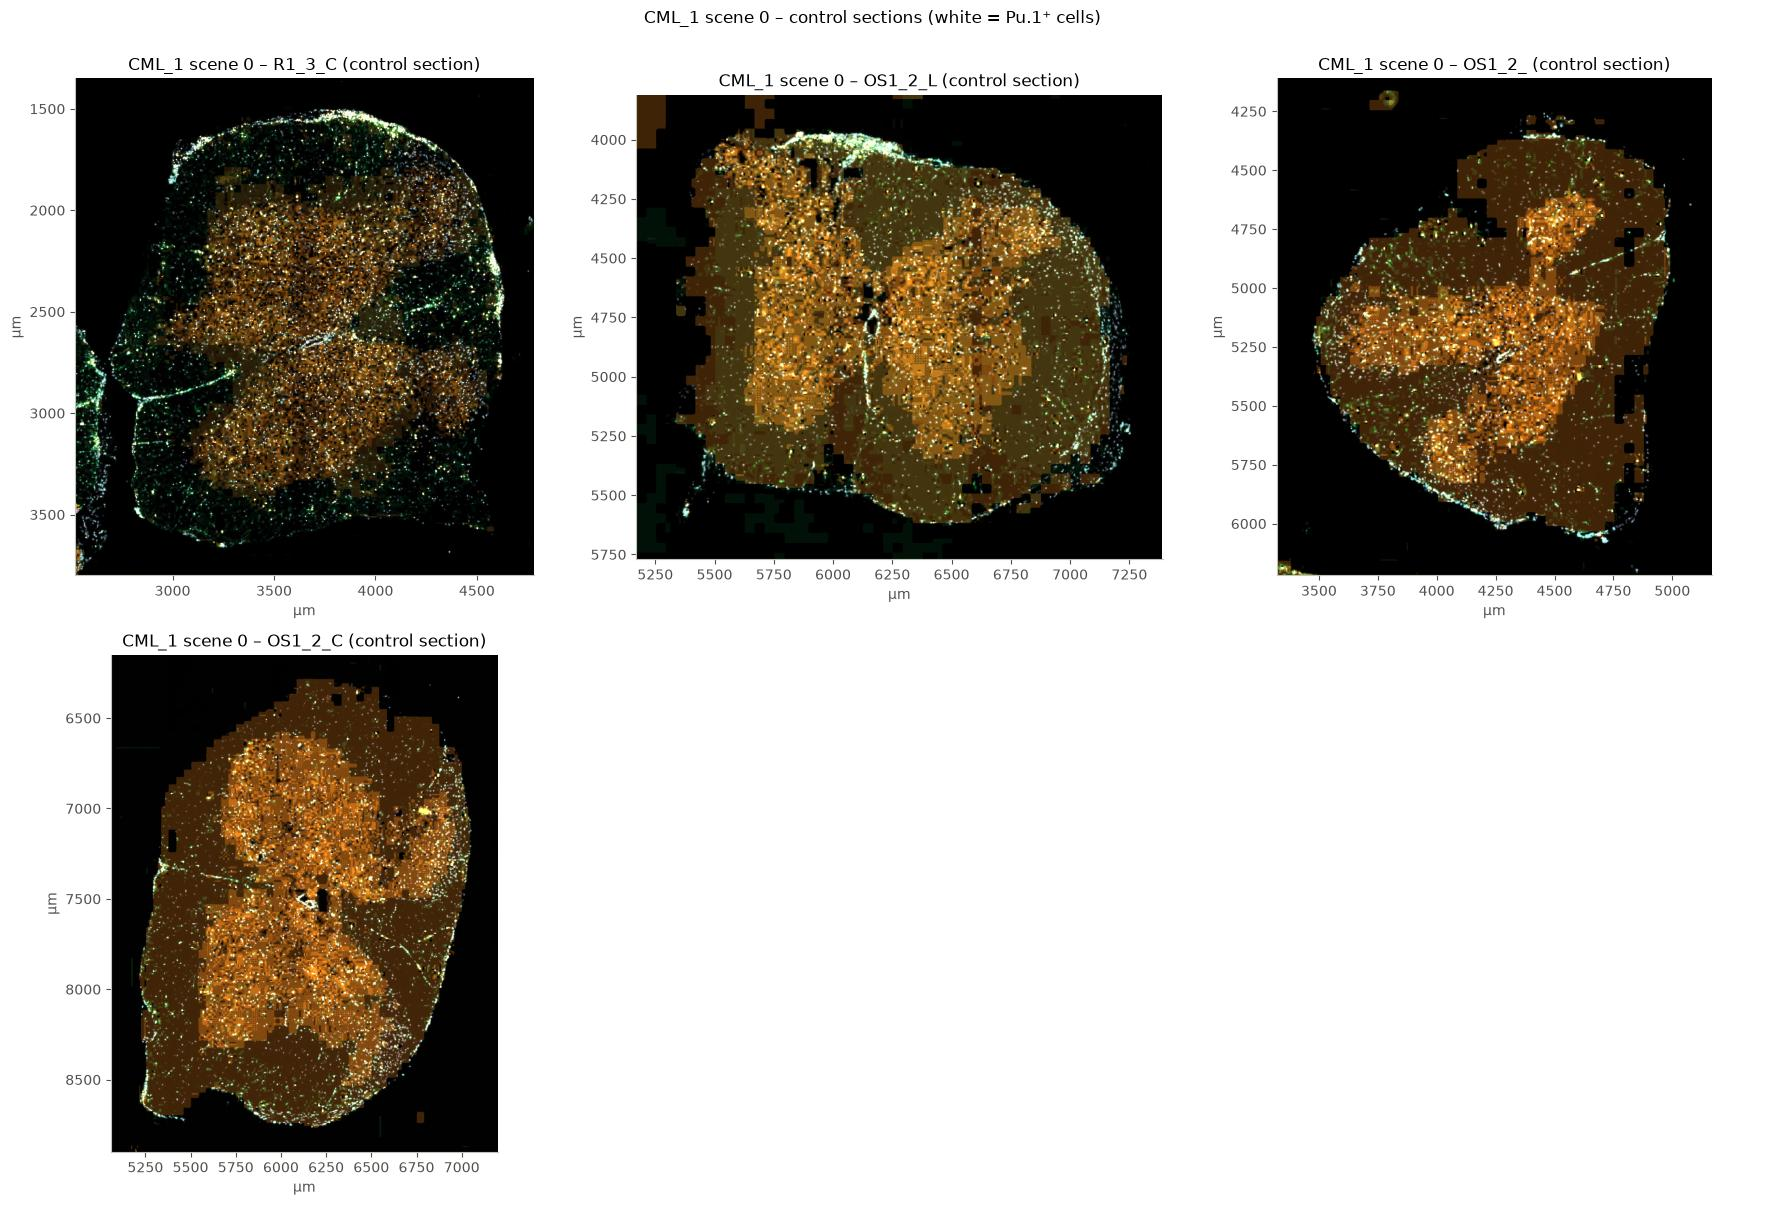

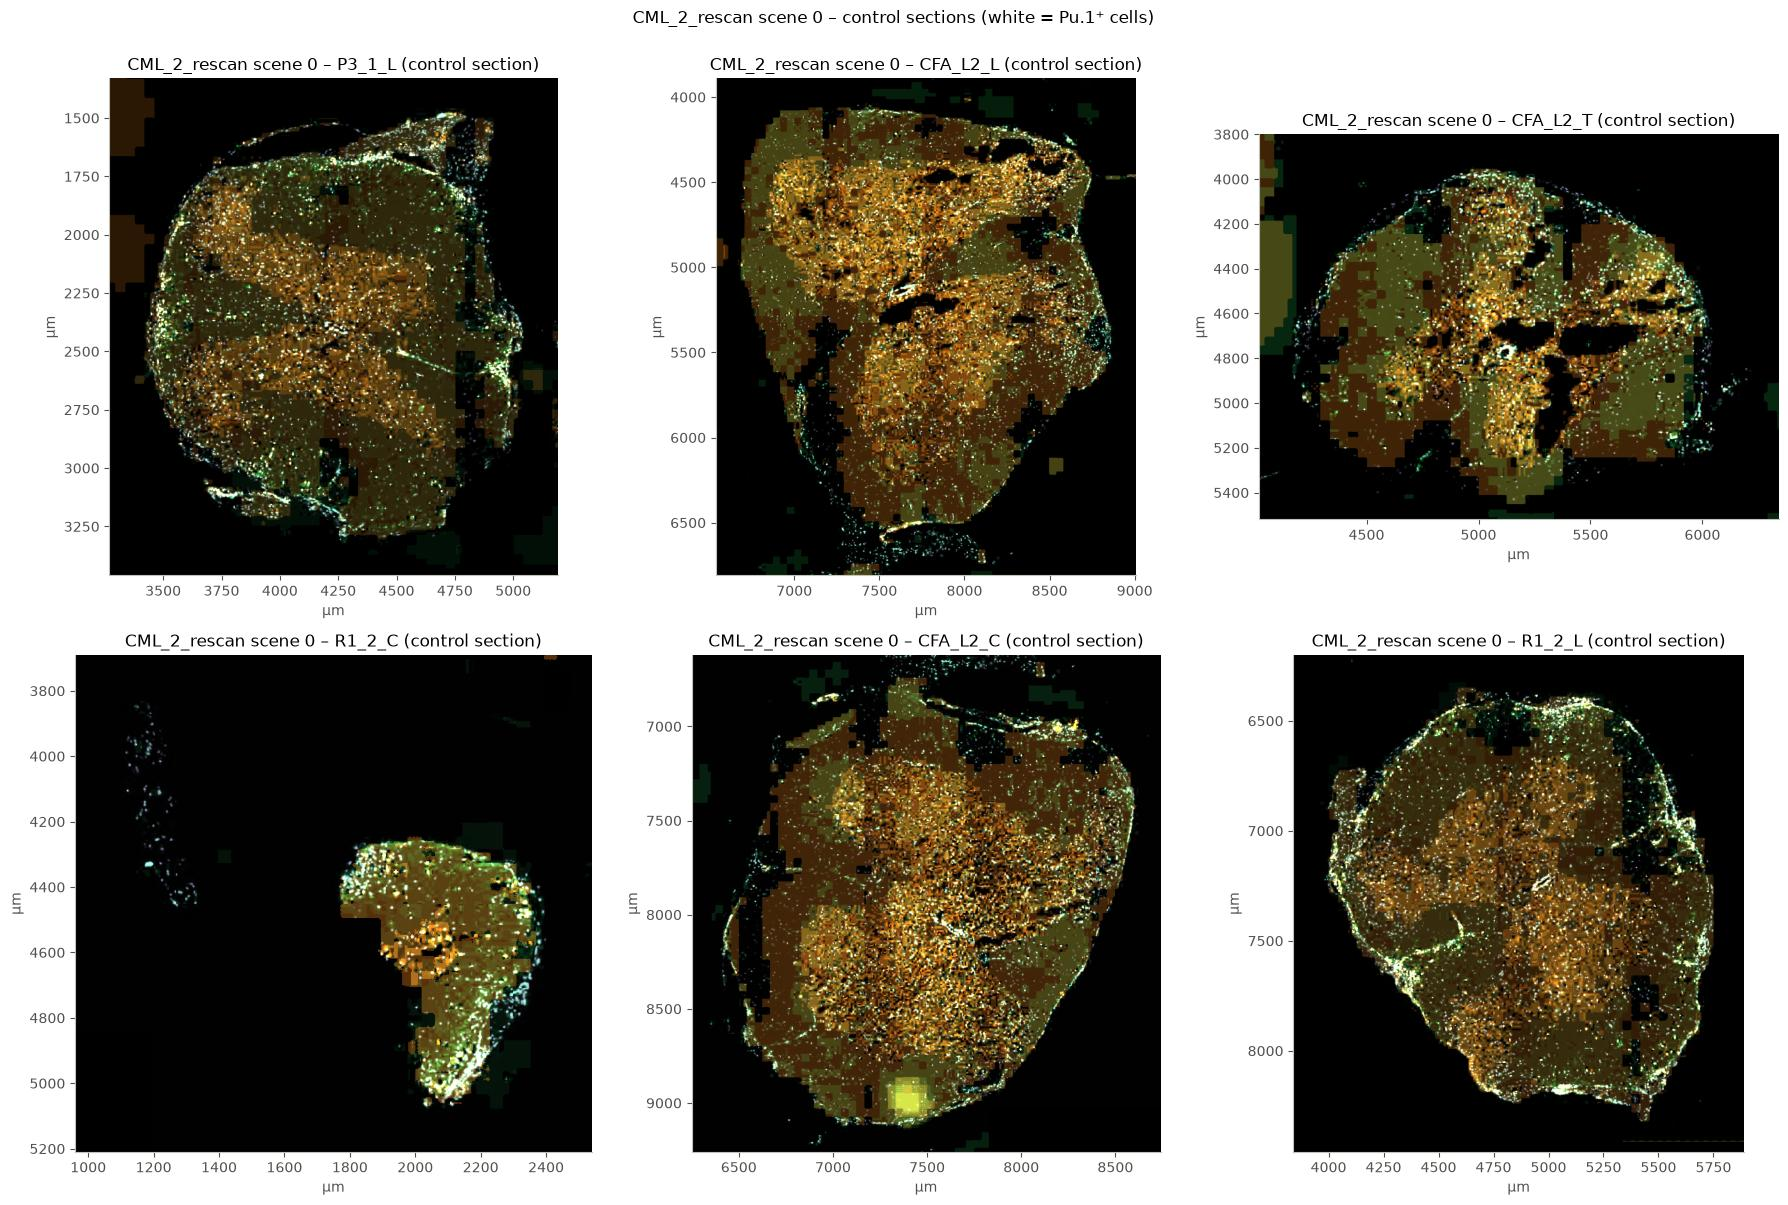

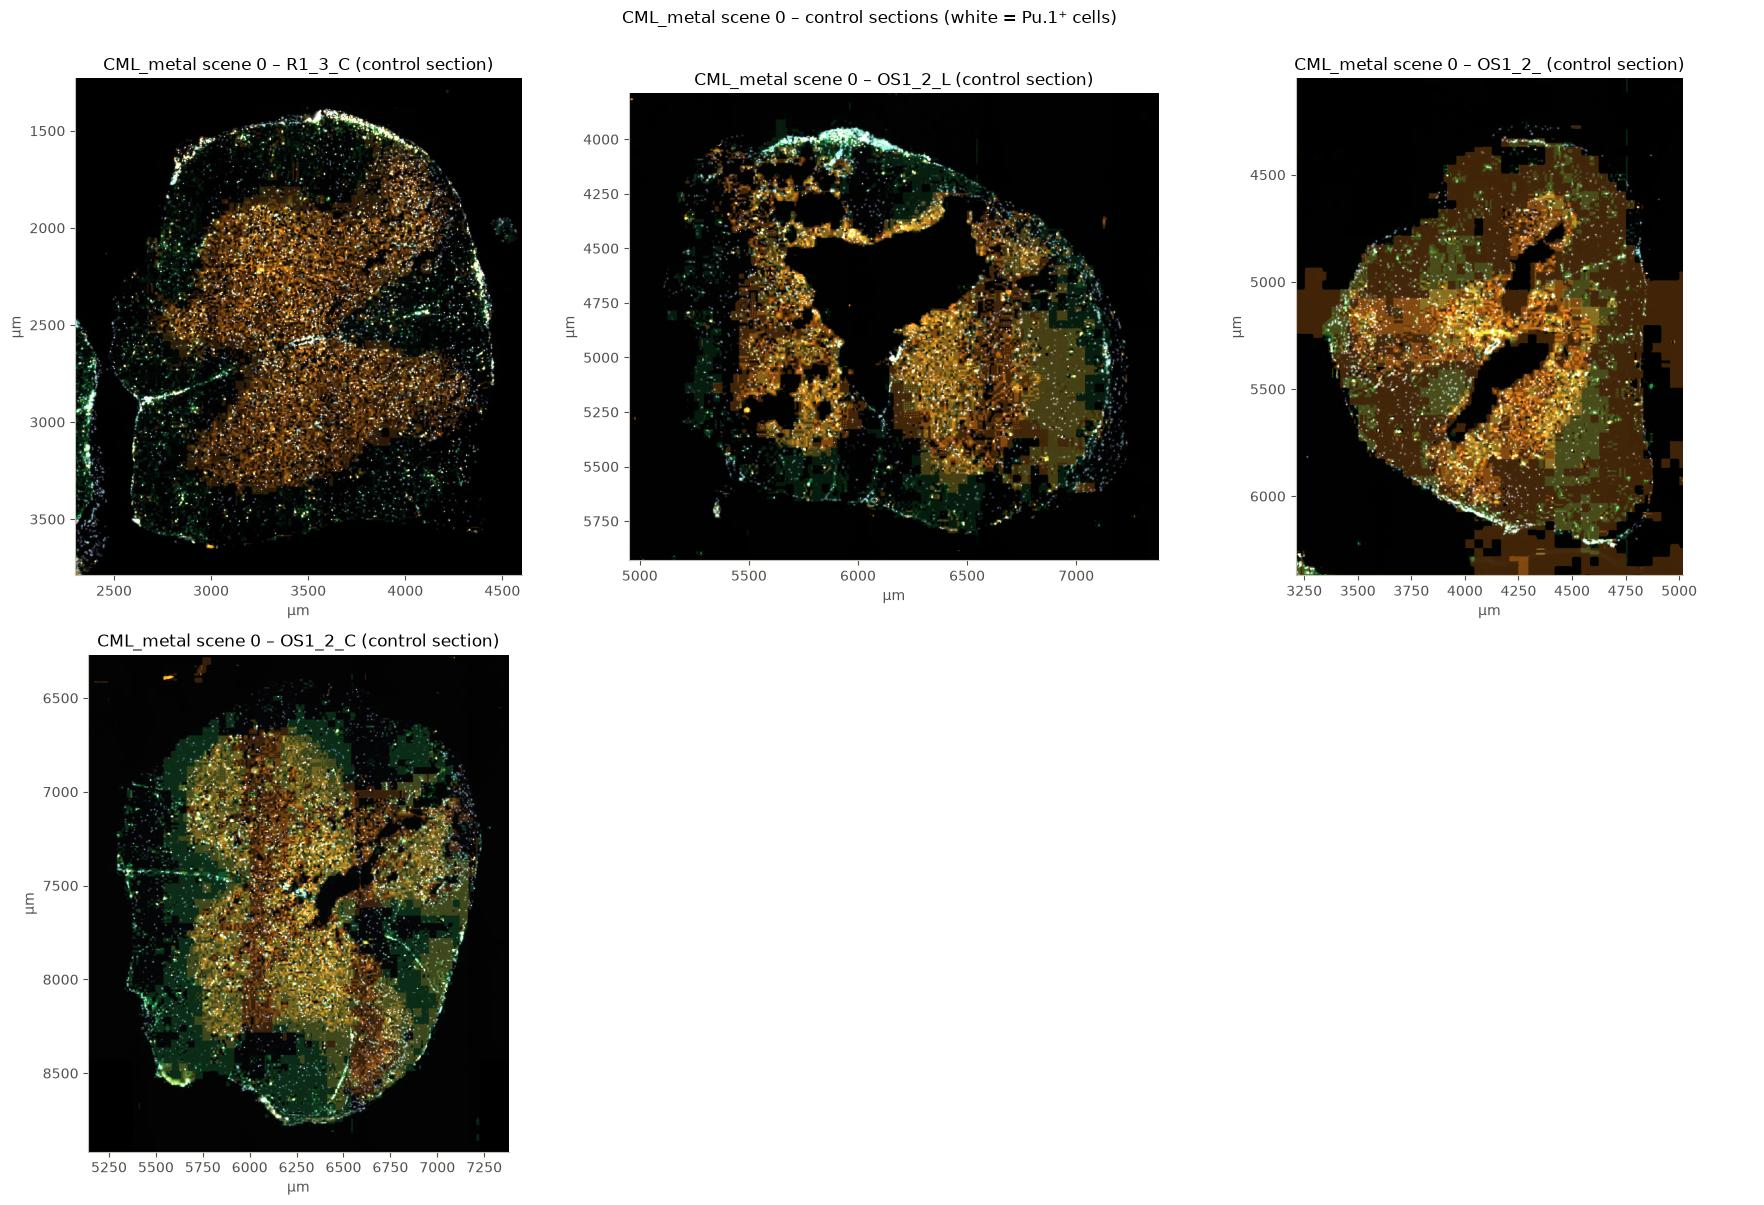

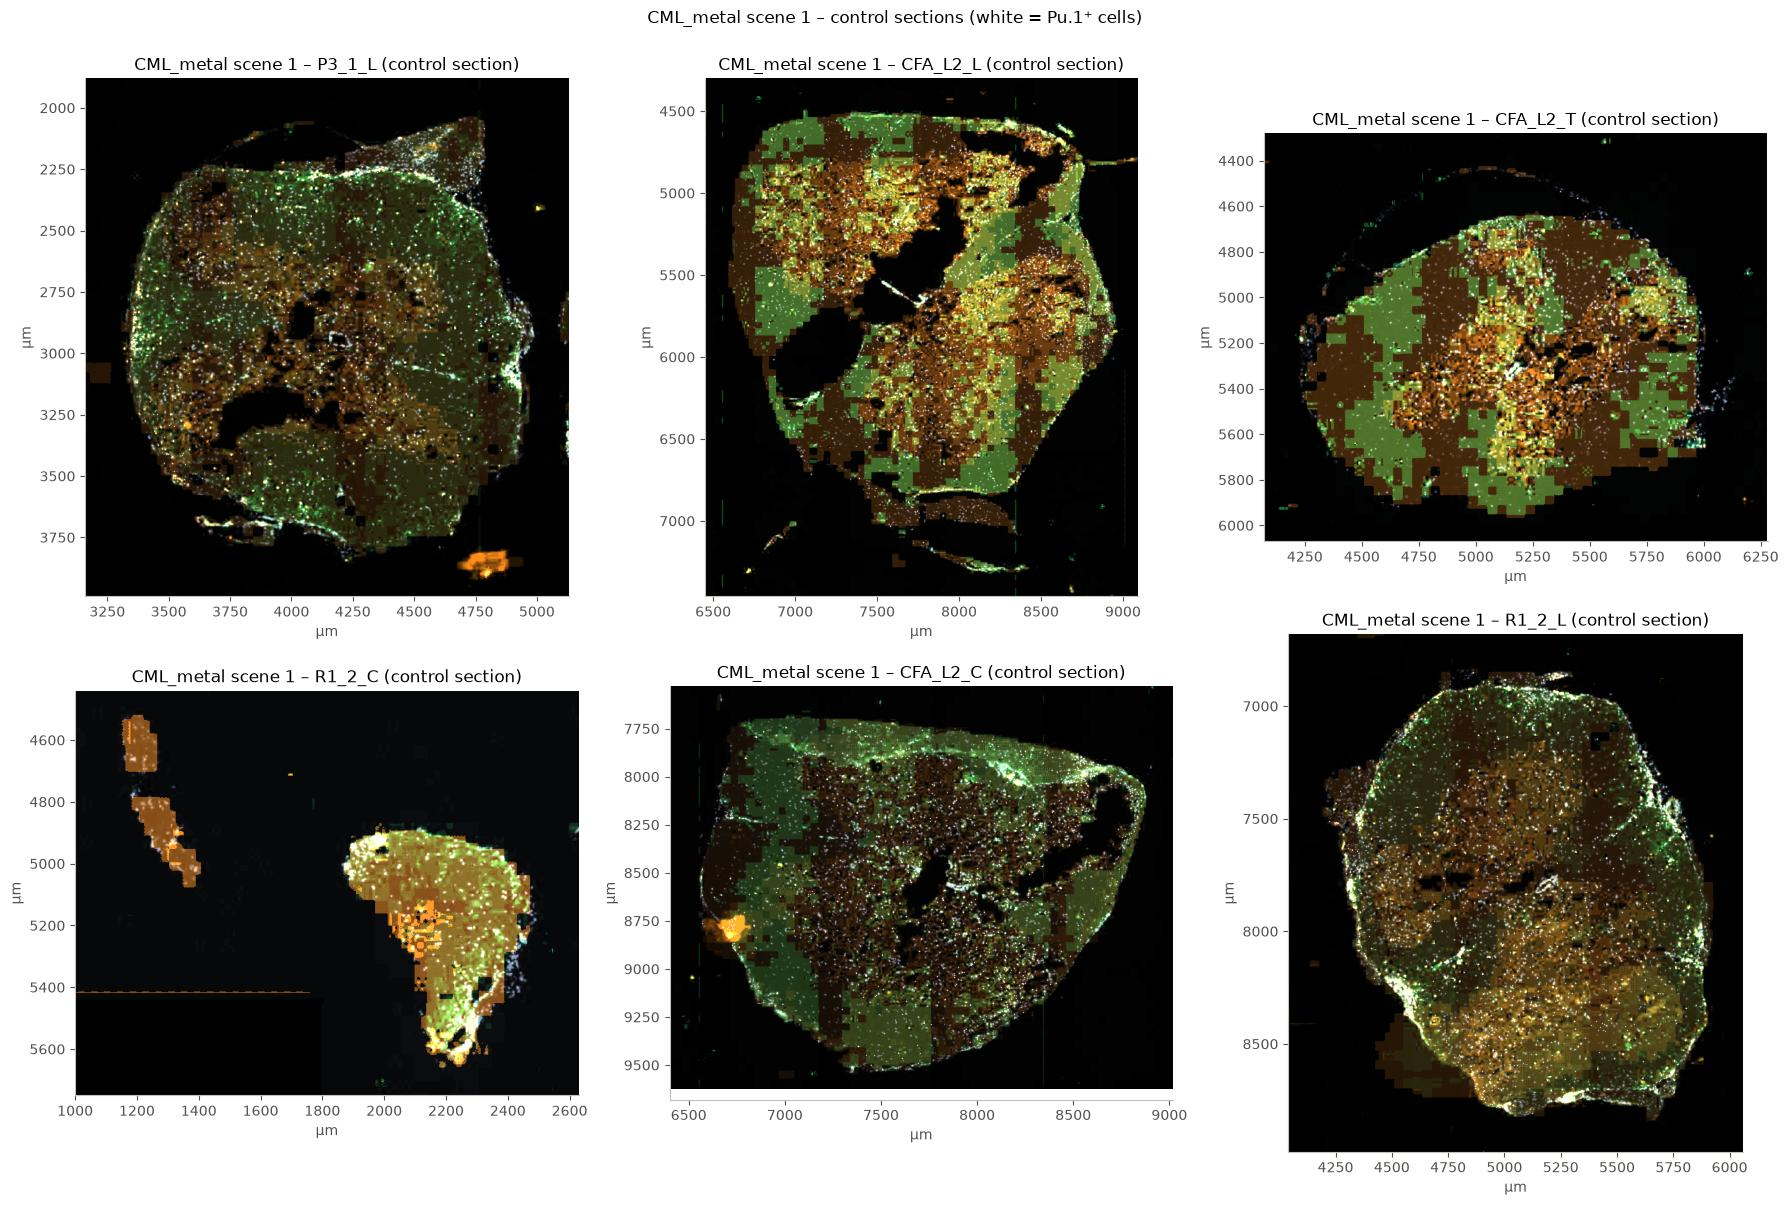

In [4]:
for r in runs:
    ctrl = r.sections[~r.sections.is_lesion_section]
    n = len(ctrl)
    if n == 0:
        continue
    fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize=(18, 6 * int(np.ceil(n / 3))), squeeze=False)
    for ax, sid in zip(axes.ravel(), ctrl.section_id):
        R.plot_section(r, int(sid), ax=ax, scale=0.12, show_cells=False)
        c = r.cells[(r.cells.section_id == sid) & r.cells.pu1_pos]
        ax.scatter(c.x_um, c.y_um, s=1, c="#ffffff", alpha=0.6, linewidths=0)
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(f"{r.name} – control sections (white = Pu.1⁺ cells)", y=1.0)
    plt.tight_layout(); plt.show()

## The score behind the calls

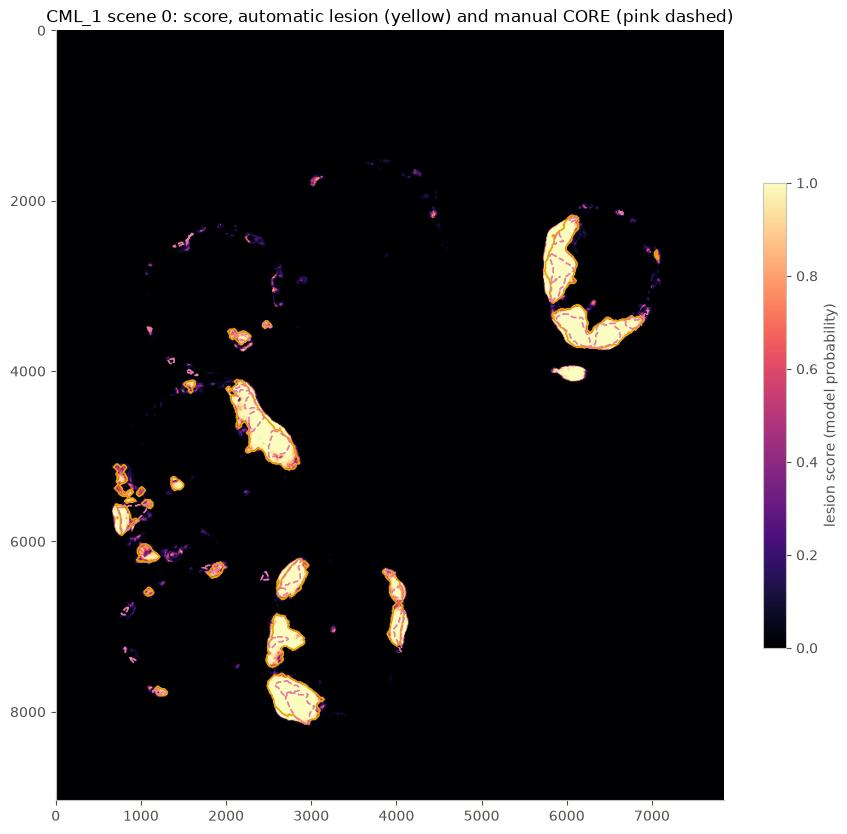

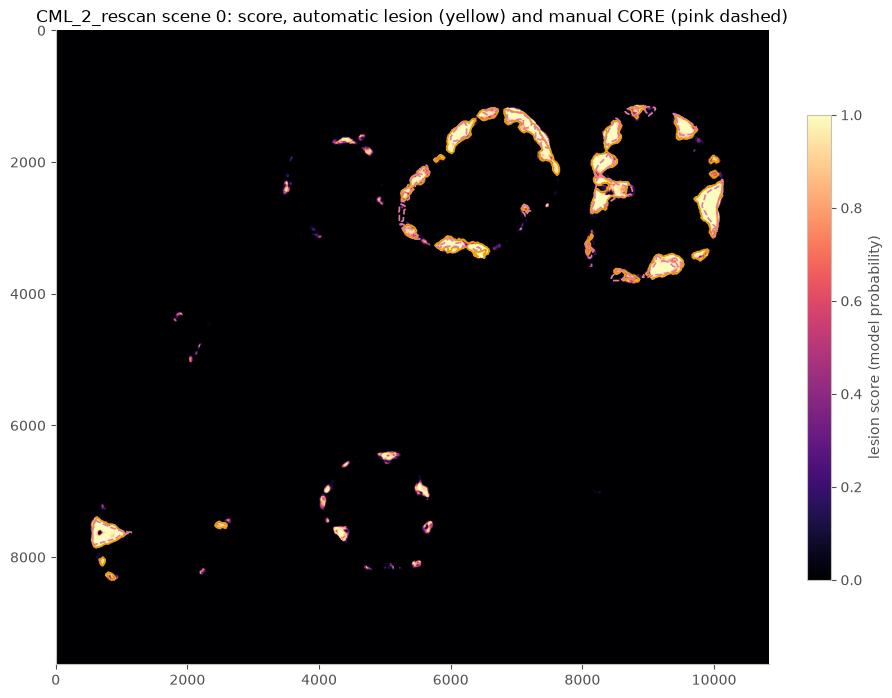

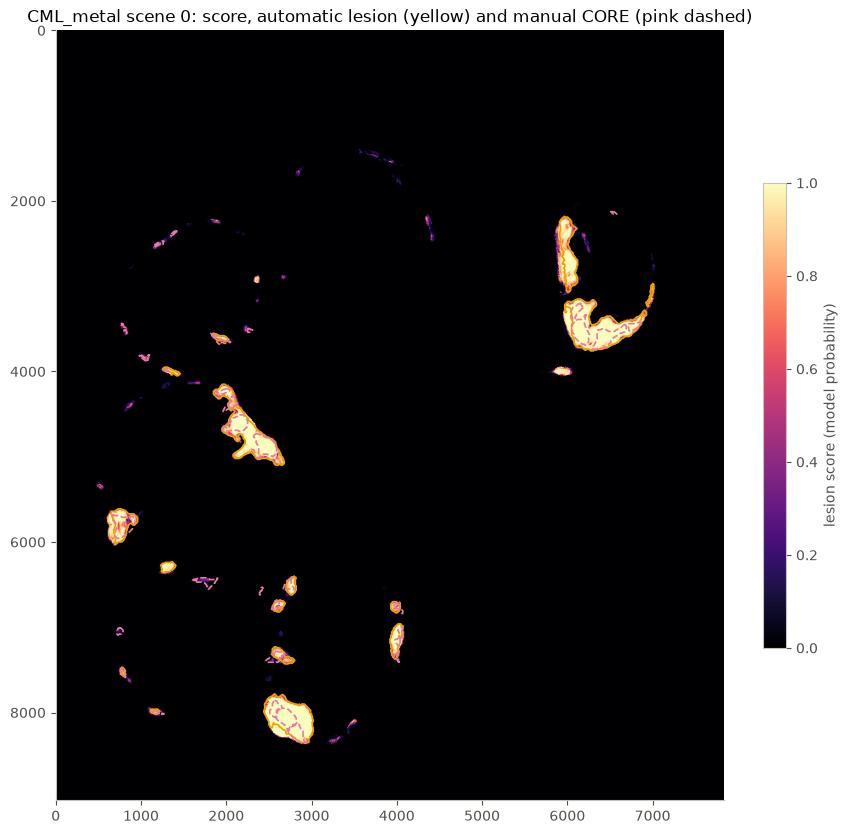

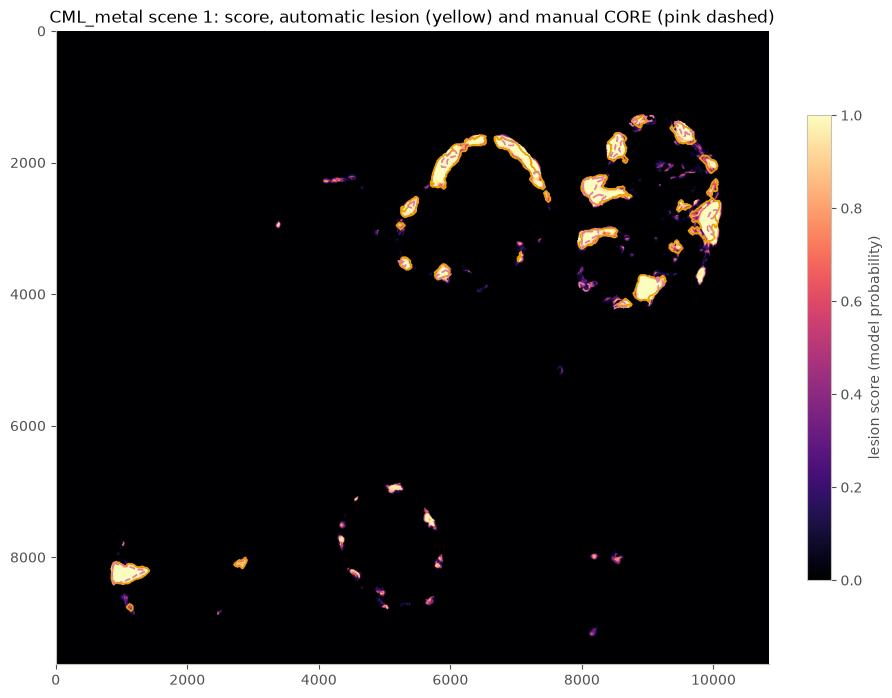

In [5]:
for r in runs:
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(r.map("lesion_score"), extent=r.extent_um, cmap="magma", vmin=0, vmax=1 if r.log["lesion"]["score"] == "model" else None)
    R.draw_outlines(ax, r, lesion=True, core=False, manual=True)
    plt.colorbar(im, ax=ax, fraction=0.03, label="lesion score" + (" (model probability)" if r.log["lesion"]["score"] == "model" else ""))
    ax.set_title(f"{r.name}: score, automatic lesion (yellow) and manual CORE (pink dashed)")
    plt.show()